# Red team du classifieur d'expressions faciales

Projet Deep Learning, Master 1 (2026-2027). Thibaut Laheurte

Ce notebook accompagne le notebook principal du projet. Dans le notebook principal on construit le CNN ; ici on essaie de le mettre en défaut.

Le principe vient de la sécurité informatique : une équipe "rouge" attaque le système par tous les moyens raisonnables, et on note ce qui résiste et ce qui casse. Pour un classifieur d'expressions faciales, casser le modèle ne veut pas seulement dire le tromper avec une image trafiquée. Ça veut aussi dire montrer que le score annoncé est gonflé, que le modèle s'effondre quand la photo est un peu sombre ou mal cadrée, ou qu'il affirme voir de la colère avec 90 % de confiance sur quelque chose qui n'est pas un visage. Ces défauts-là arriveront en conditions réelles bien avant qu'un attaquant s'intéresse à notre modèle, donc on leur laisse autant de place qu'aux attaques adversariales.

Quelques principes qu'on a suivis du début à la fin :

- les hypothèses sont écrites avant les expériences (partie 0), pour ne pas raconter après coup ce qu'on "attendait" ;
- le jeu de test sert uniquement à mesurer, jamais à régler quoi que ce soit ;
- les chiffres importants ont un intervalle de confiance, sinon on ne sait pas si un écart de deux points veut dire quelque chose ;
- chaque attaque a un témoin (bruit aléatoire de même amplitude, patch aléatoire de même taille) et des contrôles qui vérifient qu'elle est bien codée. Une attaque buggée donne l'impression que le modèle est robuste, c'est l'erreur la plus classique dans ce domaine.

**Exécution.** Sur Colab, choisir un GPU (Exécution > Modifier le type d'exécution > T4) puis Exécution > Tout exécuter. Pour attaquer notre modèle final, il suffit de déposer le fichier `.keras` sauvegardé dans le notebook principal (`model.save("modele_final.keras")`) dans le panneau Fichiers de Colab, à l'emplacement indiqué par `MODEL_PATH`. Sinon le notebook entraîne un CNN de référence avec le même prétraitement que le notebook principal (48×48, niveaux de gris, pixels divisés par 255). Avec `RAPIDE = True` tout est réduit, ça permet de vérifier en quelques minutes que rien ne plante.

**Sommaire**

0. Cadre : ce qu'on attaque, modèle de menace, hypothèses
1. Mise en place et données
2. Audit du dataset
3. Le modèle cible, et ce que vaut vraiment son score
4. Conditions réelles dégradées
5. Occlusions : ce que le modèle regarde
6. Attaques adversariales
7. Images qui ne sont pas des visages
8. Contre-mesures, puis nouveau passage de la red team
9. Bilan

## 0. Cadre de la red team

### Ce qu'on attaque

Le système final du projet, c'est la chaîne image ou vidéo → détecteur de visages (YOLO) → recadrage → CNN → expression et probabilité. La red team vise surtout le CNN, mais on garde la chaîne complète en tête : plusieurs tests reproduisent ce que le détecteur enverra vraiment au CNN, c'est-à-dire des visages mal cadrés, en basse résolution, et de temps en temps des choses qui ne sont pas des visages du tout.

### Modèle de menace

| | Scénario | Qui ou quoi | Moyens | Ce qu'on mesure | Partie |
|---|---|---|---|---|---|
| A | Le score annoncé est faux | le dataset lui-même | doublons entre train et test, labels erronés | écart entre score brut et score corrigé | 2, 3 |
| B | Conditions réelles | personne, juste la caméra | image sombre, floue, compressée, visage mal cadré, tête penchée, masque | accuracy selon le niveau de dégradation | 4, 5 |
| C | Entrées hors domaine | le détecteur | un faux positif de YOLO (mur, main, objet) arrive jusqu'au CNN | confiance du modèle sur ces images, possibilité de les rejeter | 7 |
| D | Attaque boîte blanche | quelqu'un qui a nos poids | perturbation invisible, ‖δ‖∞ ≤ ε | accuracy sous FGSM et PGD | 6.1, 6.2 |
| E | Attaque boîte noire | quelqu'un sans nos poids | entraîne son propre modèle sur FER2013 (public) et transfère ses attaques | taux de transfert | 6.3 |
| F | Attaque physique | une personne devant la caméra | un autocollant sur le front | taux de réussite d'un patch universel | 6.4 |

Le scénario D est le moins réaliste pour nous (personne n'a nos poids), mais c'est le pire cas et il sert de borne : un modèle qui résiste en boîte blanche résiste aussi au reste. L'inverse n'est pas vrai. C'est pour ça qu'on teste aussi E et F, qui demandent beaucoup moins de moyens à l'attaquant.

### Règles qu'on s'impose

- On garde le découpage officiel de FER2013 : *Training* pour entraîner, *PublicTest* pour valider (early stopping, température de calibration, seuils), *PrivateTest* pour mesurer. Aucun réglage n'est fait sur *PrivateTest*.
- Les dégradations et les occlusions sont testées sur tout le test. Les attaques adversariales, plus coûteuses, tournent sur un sous-ensemble fixe de `N_EVAL` images de test tiré une seule fois avec une graine. Tous les modèles passent sur les mêmes images avec les mêmes perturbations, on peut donc les comparer image par image.
- Les accuracies sont données avec un intervalle de confiance à 95 % (bootstrap, ou Wilson pour les rappels par classe).
- Chaque attaque a un témoin et des contrôles de cohérence.
- Les contre-mesures de la partie 8 sont évaluées avec des attaques adaptatives : on relance les attaques contre le modèle défendu au lieu de réutiliser celles fabriquées contre l'ancien modèle.

### Hypothèses, écrites avant les expériences

On les note ici, chacune avec un critère chiffré, pour pouvoir dire honnêtement à la fin lesquelles étaient fausses. Le verdict est calculé automatiquement dans la partie 9.

- **H1.** FER2013 contient des quasi-doublons entre le train et le test, et le modèle fait mieux sur ces images-là, donc l'accuracy de test est un peu gonflée. *Critère : accuracy plus haute sur les images doublonnées, test exact de Fisher p < 0,05.*
- **H2.** Une partie importante des "erreurs" du modèle sont en fait des erreurs d'annotation. FER+ (Barsoum et al., 2016), qui a fait réannoter chaque image de FER2013 par 10 personnes, permet de le vérifier. *Critère : dans au moins 20 % des erreurs, le modèle dit la même chose que la majorité FER+.*
- **H3.** Le modèle est sur-confiant : quand il annonce 80 %, il a raison moins de 80 % du temps. *Critère : température optimale T > 1 et ECE avant calibration > 3 %.*
- **H4.** Le mauvais cadrage et la basse résolution, qui sont exactement ce que produira le pipeline YOLO, font plus de dégâts que le bruit ou la compression. *Critère : au niveau 3, la pire des deux dépasse la pire entre bruit et JPEG.*
- **H5.** La joie est reconnue presque uniquement grâce à la bouche. *Critère : avec un masque chirurgical, le rappel de la joie perd plus de 30 points.*
- **H6.** Sans défense, une perturbation invisible suffit à casser le modèle. *Critère : accuracy sous PGD inférieure à 10 % à ε = 2/255.*
- **H7.** Des attaques fabriquées sur un modèle substitut transfèrent vers notre modèle. *Critère : à ε = 4/255, accuracy au moins 10 points sous celle du témoin bruit.*
- **H8.** Le modèle ne sait pas dire qu'une image n'est pas un visage. *Critère : plus de 20 % des images CIFAR-10 passent un seuil de confiance qui garde 95 % des vrais visages.*
- **H9.** L'entraînement adversarial améliore nettement la robustesse, au prix de quelques points sur les images normales. *Critère : au moins +20 points sous PGD à 2/255, et au moins 1 point perdu sur les images normales.*

### Grille de gravité

Elle aussi fixée avant de voir les résultats :

- **critique** : se produit sans attaquant, dans l'usage normal du pipeline, et coûte plus de 15 points d'accuracy (ou fausse le score annoncé de plus de 2 points) ;
- **élevée** : se produit sans attaquant avec un impact de 5 à 15 points, ou bien attaque faisable sans accès au modèle (boîte noire, patch) ;
- **moyenne** : demande un accès privilégié (boîte blanche) ou coûte moins de 5 points.

## 1. Mise en place

Tous les réglages sont regroupés dans la cellule suivante.

In [1]:
RAPIDE = False        # True : petits sous-ensembles et peu d'epochs, juste pour verifier que tout tourne
MODEL_PATH = "/content/modele_final.keras"   # modele final du notebook principal (sinon on en entraine un ici)
PIXEL_MAX = 1.0       # 1.0 si le modele attend des pixels dans [0, 1], 255.0 s'il normalise lui-meme
SEED = 42

N_EVAL = 300 if RAPIDE else 1000           # images de test pour les tests couteux
EPOCHS = 3 if RAPIDE else 60               # max, l'early stopping coupe avant
EPOCHS_DURCI = 2 if RAPIDE else 30
PAS_PATCH = 40 if RAPIDE else 500

# grille de gravite de la partie 0, en points d'accuracy
SEUIL_CRITIQUE = 15
SEUIL_ELEVE = 5

In [2]:
import os, io, time, hashlib, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
from keras import layers
from PIL import Image
from scipy import ndimage, stats
from scipy.optimize import minimize_scalar
from sklearn.metrics import confusion_matrix, f1_score, balanced_accuracy_score, roc_auc_score
from IPython.display import display

keras.utils.set_random_seed(SEED)
print("tensorflow", tf.__version__, "| keras", keras.__version__)
print("GPU :", tf.config.list_physical_devices("GPU"))

CLASSES = ["Colere", "Degout", "Peur", "Joie", "Tristesse", "Surprise", "Neutre"]
JOIE, COLERE = 3, 0

def fichier(nom):
    # en mode RAPIDE on ne melange pas les modeles avec ceux du vrai run
    return nom.replace(".keras", "_rapide.keras") if RAPIDE else nom

tensorflow 2.21.0 | keras 3.13.2
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Les données

On utilise FER2013 (Goodfellow et al., 2013) : 35 887 visages en niveaux de gris de 48×48 pixels, 7 classes. Les images ont été trouvées avec l'API Google Images à partir de mots-clés liés aux émotions, les visages ont été recadrés automatiquement avec OpenCV, puis des annotateurs ont retiré les images mal étiquetées et "une partie" des doublons. Ce dernier détail est important pour la partie 2.

La version Kaggle la plus utilisée réunit *PublicTest* et *PrivateTest* dans un seul dossier `test`. On passe plutôt par un miroir Hugging Face qui garde les trois parties d'origine, et on fige la révision pour que le notebook télécharge toujours exactement les mêmes fichiers. Côté licence, FER2013 a été diffusé pour un concours de recherche (ICML 2013) et les images viennent du web : on s'en sert pour ce travail, mais on ne les redistribue pas. Les labels FER+ utilisés plus loin sont publiés par Microsoft sous licence MIT.

In [3]:
DOSSIER = "donnees_fer"
os.makedirs(DOSSIER, exist_ok=True)

HF = ("https://huggingface.co/datasets/Aaryan333/fer2013_train_publicTest_privateTest/resolve/"
      "da8d1643649c86bfc2cffba5b744b51fdf329212/data/")
SOURCES = {
    "train": HF + "train-00000-of-00001-5eab84e1c6a2fc27.parquet",
    "val": HF + "publicTest-00000-of-00001-f41bb7384b8aad6e.parquet",
    "test": HF + "privateTest-00000-of-00001-4b8a0715cf1b7560.parquet",
}
FERPLUS = "https://raw.githubusercontent.com/microsoft/FERPlus/ae2128abf776409c93e50cf7c9d87180673314e6/fer2013new.csv"

def telecharger(url, nom):
    chemin = os.path.join(DOSSIER, nom)
    if not os.path.exists(chemin):
        urllib.request.urlretrieve(url, chemin)
    return chemin

def lire_parquet(chemin):
    df = pd.read_parquet(chemin)
    x = np.stack([np.array(Image.open(io.BytesIO(d["bytes"])).convert("L")) for d in df["image"]])
    return x, df["label"].to_numpy().astype("int32")

t0 = time.time()
x8_tr, y_tr = lire_parquet(telecharger(SOURCES["train"], "train.parquet"))
x8_va, y_va = lire_parquet(telecharger(SOURCES["val"], "val.parquet"))
x8_te, y_te = lire_parquet(telecharger(SOURCES["test"], "test.parquet"))
print(f"charge en {time.time() - t0:.0f} s")
print("train", x8_tr.shape, "| val", x8_va.shape, "| test", x8_te.shape, "|", x8_tr.dtype)

# meme pretraitement que dans le notebook principal : float32 dans [0, 1], un canal
def preparer(x8):
    return (x8.astype("float32") / 255)[..., None]

x_tr, x_va, x_te = preparer(x8_tr), preparer(x8_va), preparer(x8_te)

charge en 24 s
train (28709, 48, 48) | val (3589, 48, 48) | test (3589, 48, 48) | uint8


Ce miroir a été mis en ligne par un particulier. Avant de lui faire confiance, on vérifie qu'il correspond au `fer2013.csv` d'origine en comparant les effectifs par classe de chaque partie.

In [4]:
# effectifs du fer2013.csv d'origine, dans l'ordre Colere, Degout, Peur, Joie, Tristesse, Surprise, Neutre
ORIGINAL = {
    "train": [3995, 436, 4097, 7215, 4830, 3171, 4965],
    "val":   [467, 56, 496, 895, 653, 415, 607],
    "test":  [491, 55, 528, 879, 594, 416, 626],
}
for nom, yy in [("train", y_tr), ("val", y_va), ("test", y_te)]:
    obtenu = np.bincount(yy, minlength=7).tolist()
    print(f"{nom:5s} {obtenu}  ->", "identique a l'original" if obtenu == ORIGINAL[nom] else "DIFFERENT")

effectifs = pd.DataFrame({k: np.bincount(v, minlength=7) for k, v in [("train", y_tr), ("val", y_va), ("test", y_te)]},
                         index=CLASSES)
effectifs["% du train"] = (100 * effectifs["train"] / effectifs["train"].sum()).round(1)
effectifs

train [3995, 436, 4097, 7215, 4830, 3171, 4965]  -> identique a l'original
val   [467, 56, 496, 895, 653, 415, 607]  -> identique a l'original
test  [491, 55, 528, 879, 594, 416, 626]  -> identique a l'original


,train,val,test,% du train
Colere,3995,467,491,13.9
Degout,436,56,55,1.5
Peur,4097,496,528,14.3
Joie,7215,895,879,25.1
Tristesse,4830,653,594,16.8
Surprise,3171,415,416,11.0
Neutre,4965,607,626,17.3


Rappel du déséquilibre : le dégoût représente 1,5 % du train, la joie 25 %. Un modèle qui répond toujours "Joie" a déjà 24,5 % d'accuracy sur le test. C'est la vraie référence plancher, pas les 14 % du hasard.

## 2. Audit du dataset

Avant d'attaquer le modèle, on attaque les données. Si le jeu de test est contaminé ou mal annoté, tous les chiffres du projet sont faussés, y compris ceux de l'analyse d'erreurs du notebook principal, et aucune des expériences de la partie 6 ne peut corriger ça.

### 2.1 Doublons exacts

On calcule une empreinte (hash MD5) des pixels de chaque image. Deux images avec la même empreinte sont identiques au pixel près.

In [5]:
def empreinte(img):
    return hashlib.md5(img.tobytes()).hexdigest()

h_tr = np.array([empreinte(im) for im in x8_tr])
h_va = np.array([empreinte(im) for im in x8_va])
h_te = np.array([empreinte(im) for im in x8_te])

set_tr = set(h_tr)
exact_te = np.array([h in set_tr for h in h_te])
exact_va = np.array([h in set_tr for h in h_va])
print("test : images identiques a une image du train       :", exact_te.sum())
print("val  : images identiques a une image du train       :", exact_va.sum())
print("test : images identiques a une image de validation  :", len(set(h_te) & set(h_va)))

# doublons a l'interieur du train, et doublons qui n'ont pas le meme label
groupes = pd.DataFrame({"h": h_tr, "y": y_tr}).groupby("h")["y"].agg(["size", "nunique"])
groupes = groupes[groupes["size"] > 1]
conflits = groupes[groupes["nunique"] > 1]
print(f"\ntrain : {len(groupes)} groupes d'images identiques ({groupes['size'].sum()} images au total)")
print(f"        dont {len(conflits)} groupes ou la meme image porte des labels differents")

test : images identiques a une image du train       : 288
val  : images identiques a une image du train       : 280
test : images identiques a une image de validation  : 43

train : 1035 groupes d'images identiques (2271 images au total)
        dont 39 groupes ou la meme image porte des labels differents


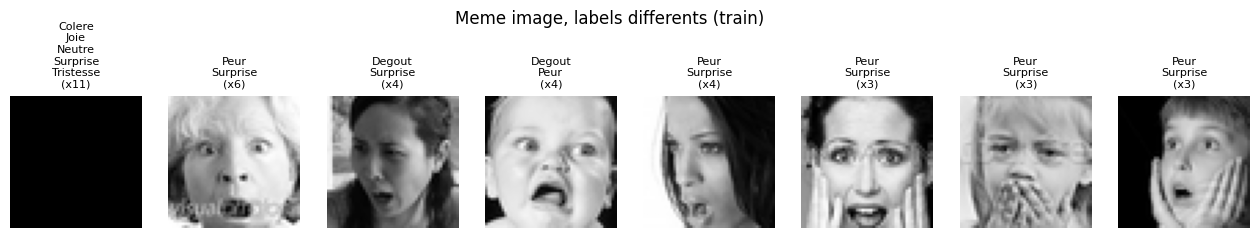

In [6]:
# quelques images du train presentes plusieurs fois avec des labels differents
montrer = conflits.sort_values("size", ascending=False).index[:8]
if len(montrer):
    fig, axes = plt.subplots(1, len(montrer), figsize=(2 * len(montrer), 2.6))
    for ax, h in zip(np.atleast_1d(axes), montrer):
        idx = np.where(h_tr == h)[0]
        ax.imshow(x8_tr[idx[0]], cmap="gray", vmin=0, vmax=255)
        ax.set_title("\n".join(sorted({CLASSES[y_tr[i]] for i in idx})) + f"\n(x{len(idx)})", fontsize=8)
        ax.axis("off")
    plt.suptitle("Meme image, labels differents (train)", y=1.08)
    plt.show()

288 images du test, soit 8 %, sont copiées à l'identique dans le train, et c'est pareil pour la validation (280 images). Les créateurs de FER2013 avaient retiré "une partie" des doublons : il en reste beaucoup. Concrètement, le modèle a déjà vu les réponses d'une partie de l'examen.

À l'intérieur du train, 39 images apparaissent plusieurs fois avec des labels différents. Le cas le plus parlant est une image entièrement noire, présente 11 fois sous cinq émotions différentes : on demande au modèle d'y voir à la fois de la colère, de la joie et de la tristesse. Ce sont des déchets de collecte, en petit nombre, mais ils montrent que les labels n'ont pas été vérifiés image par image.

### 2.2 Quasi-doublons

Le hash ne voit que les copies parfaites. La même photo peut aussi revenir recadrée de quelques pixels, un peu plus claire, recompressée, ou retournée en miroir. Pour les attraper, on réduit chaque image en 24×24, on la centre et on la normalise, puis on calcule la similarité cosinus avec toutes les images du train (un simple produit matriciel). Deux photos de personnes différentes restent assez loin de 1 ; deux versions de la même photo en sont très proches. On compare aussi chaque image de test avec la version miroir des images du train.

Le seuil ne sort pas de nulle part. On regarde d'abord la distribution des similarités, puis on affiche les paires juste au-dessus et juste en dessous du seuil pour vérifier à l'œil.

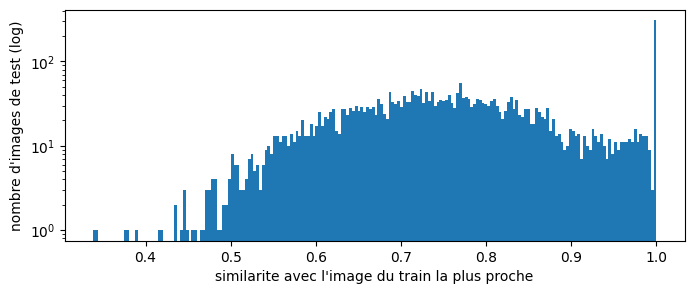

seuil 0.90 :  639 images de test,  604 images de validation
seuil 0.93 :  527 images de test,  502 images de validation
seuil 0.95 :  465 images de test,  440 images de validation
seuil 0.97 :  399 images de test,  377 images de validation
seuil 0.99 :  320 images de test,  299 images de validation


In [7]:
def signatures(x8, taille=24, miroir=False):
    im = x8[:, :, ::-1] if miroir else x8
    v = tf.image.resize(im[..., None].astype("float32"), (taille, taille), method="area").numpy().reshape(len(im), -1)
    v = v - v.mean(1, keepdims=True)
    return v / (np.linalg.norm(v, axis=1, keepdims=True) + 1e-6)

def plus_proche(requetes, base, bloc=1000):
    sim = np.zeros(len(requetes), "float32")
    idx = np.zeros(len(requetes), "int64")
    for i in range(0, len(requetes), bloc):
        s = requetes[i:i + bloc] @ base.T
        idx[i:i + bloc] = s.argmax(1)
        sim[i:i + bloc] = s.max(1)
    return sim, idx

def voisin_dans_train(x8):
    sim, idx = plus_proche(signatures(x8), sig_tr)
    sim_m, idx_m = plus_proche(signatures(x8, miroir=True), sig_tr)
    miroir = sim_m > sim
    return np.maximum(sim, sim_m), np.where(miroir, idx_m, idx), miroir

sig_tr = signatures(x8_tr)
sim_te, voisin_te, miroir_te = voisin_dans_train(x8_te)
sim_va, voisin_va, miroir_va = voisin_dans_train(x8_va)

plt.figure(figsize=(8, 3))
plt.hist(sim_te, bins=200, log=True)
plt.xlabel("similarite avec l'image du train la plus proche")
plt.ylabel("nombre d'images de test (log)")
plt.show()
for s in [0.90, 0.93, 0.95, 0.97, 0.99]:
    print(f"seuil {s:.2f} : {np.sum(sim_te >= s):4d} images de test, {np.sum(sim_va >= s):4d} images de validation")

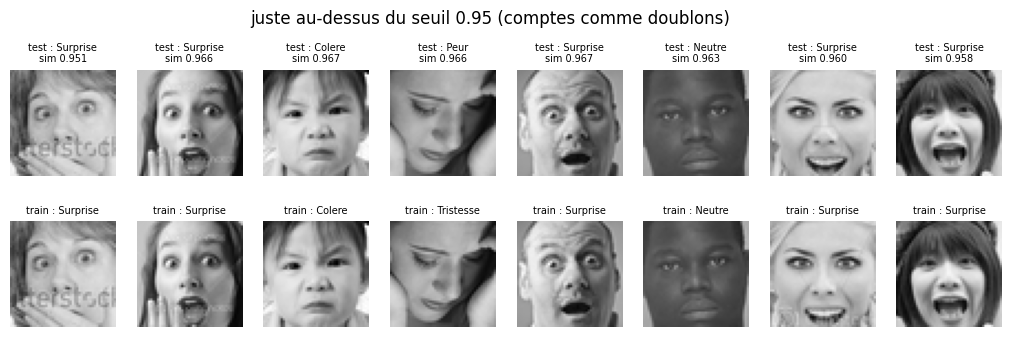

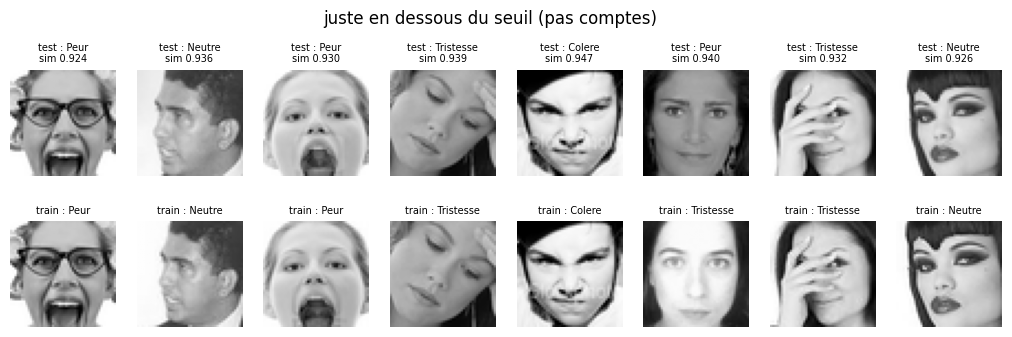

test : 465 images ont un quasi-doublon dans le train (13.0 %), dont 4 en miroir
       labels differents entre l'image de test et son doublon : 38
val  : 440 images ont un quasi-doublon dans le train (12.3 %)


In [8]:
SEUIL_QUASI = 0.95

def montrer_paires(sel, titre):
    sel = sel[:8]
    if len(sel) < 2:
        print(titre, ": pas assez de paires a afficher")
        return
    fig, axes = plt.subplots(2, len(sel), figsize=(1.6 * len(sel), 3.6))
    for k, i in enumerate(sel):
        j = voisin_te[i]
        axes[0, k].imshow(x8_te[i], cmap="gray", vmin=0, vmax=255)
        axes[0, k].set_title(f"test : {CLASSES[y_te[i]]}\nsim {sim_te[i]:.3f}", fontsize=7)
        axes[1, k].imshow(x8_tr[j][:, ::-1] if miroir_te[i] else x8_tr[j], cmap="gray", vmin=0, vmax=255)
        axes[1, k].set_title(f"train : {CLASSES[y_tr[j]]}" + (" (miroir)" if miroir_te[i] else ""), fontsize=7)
        for ax in axes[:, k]:
            ax.axis("off")
    plt.suptitle(titre, y=1.02)
    plt.show()

rng = np.random.default_rng(0)
juste_dessus = np.where((sim_te >= SEUIL_QUASI) & (sim_te < SEUIL_QUASI + 0.02) & ~exact_te)[0]
juste_dessous = np.where((sim_te >= SEUIL_QUASI - 0.03) & (sim_te < SEUIL_QUASI))[0]
montrer_paires(rng.permutation(juste_dessus), f"juste au-dessus du seuil {SEUIL_QUASI} (comptes comme doublons)")
montrer_paires(rng.permutation(juste_dessous), f"juste en dessous du seuil (pas comptes)")

quasi_te = sim_te >= SEUIL_QUASI
quasi_va = sim_va >= SEUIL_QUASI
print(f"test : {quasi_te.sum()} images ont un quasi-doublon dans le train ({100 * quasi_te.mean():.1f} %),"
      f" dont {np.sum(quasi_te & miroir_te)} en miroir")
print(f"       labels differents entre l'image de test et son doublon : {np.sum(quasi_te & (y_te != y_tr[voisin_te]))}")
print(f"val  : {quasi_va.sum()} images ont un quasi-doublon dans le train ({100 * quasi_va.mean():.1f} %)")

Avec les quasi-doublons, on passe à 465 images de test (13 %) qui ont une version presque identique dans le train : même photo un peu recadrée, recompressée ou retouchée. Et le seuil de 0,95 est prudent : juste en dessous, la plupart des paires affichées sont encore la même photo. Ces 13 % sont donc un minimum. Parmi ces doublons, 38 n'ont pas le même label que leur jumeau du train, ce qui donne une première idée du bruit d'annotation.

Autre chose qu'on voit sur ces paires : des filigranes de banques d'images ("shutterstock"). Un filigrane est exactement le genre de détail qu'un CNN peut apprendre à la place de l'expression, si certaines émotions viennent plus souvent de certaines banques d'images (c'est ce qu'on appelle un apprentissage par raccourci, Geirhos et al., 2020). On ne le teste pas directement, mais les cartes d'occlusion de la partie 5 permettent de vérifier que le modèle regarde bien le visage et pas les bords de l'image.

### 2.3 Images dégénérées

Des images presque uniformes (écart-type des pixels très faible) ne peuvent pas contenir de visage exploitable. On les compte dans chaque partie.

train :  12 images quasi uniformes (ecart-type < 3 niveaux de gris)
val   :   1 images quasi uniformes (ecart-type < 3 niveaux de gris)
test  :   0 images quasi uniformes (ecart-type < 3 niveaux de gris)


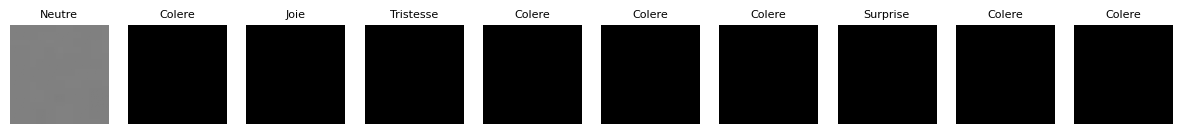

In [9]:
ecart_type = {nom: x.reshape(len(x), -1).std(1) for nom, x in [("train", x8_tr), ("val", x8_va), ("test", x8_te)]}
for nom, s in ecart_type.items():
    print(f"{nom:5s} : {np.sum(s < 3):3d} images quasi uniformes (ecart-type < 3 niveaux de gris)")

plates = np.where(ecart_type["train"] < 3)[0][:10]
if len(plates):
    fig, axes = plt.subplots(1, len(plates), figsize=(1.5 * len(plates), 1.9))
    for ax, i in zip(np.atleast_1d(axes), plates):
        ax.imshow(x8_tr[i], cmap="gray", vmin=0, vmax=255)
        ax.set_title(CLASSES[y_tr[i]], fontsize=8)
        ax.axis("off")
    plt.show()

### 2.4 Bruit d'annotation : comparaison avec FER+

FER+ (Barsoum et al., 2016) a fait réannoter les 35 887 images de FER2013 par 10 personnes chacune, avec 8 émotions (les 7 de FER2013 plus le mépris), plus "inconnu" et "pas un visage". Le fichier de votes suit l'ordre des lignes du `fer2013.csv` d'origine.

Pour chaque image on prend le choix majoritaire. S'il y a égalité en tête, on considère l'image comme ambiguë ; si la majorité choisit le mépris, "inconnu" ou "pas un visage", l'image sort des 7 classes.

Il faut d'abord vérifier que notre miroir est bien dans le même ordre que FER+, sinon on comparerait des images différentes. Le test est simple : si les fichiers sont alignés, le label FER2013 et la majorité FER+ doivent être d'accord la plupart du temps ; si on décale l'un des deux d'une ligne, l'accord doit tomber au niveau du hasard.

In [10]:
fp = pd.read_csv(telecharger(FERPLUS, "fer2013new.csv"))
VOTES = ["neutral", "happiness", "surprise", "sadness", "anger", "disgust", "fear", "contempt", "unknown", "NF"]
VERS_FER = {"anger": 0, "disgust": 1, "fear": 2, "happiness": 3, "sadness": 4, "surprise": 5, "neutral": 6}
AMBIGU, HORS_CLASSES, PAS_UN_VISAGE = -1, -2, -3

def labels_ferplus(usage):
    votes = fp[fp["Usage"] == usage][VOTES].to_numpy()
    gagnant = votes.argmax(1)
    tri = np.sort(votes, axis=1)
    lab = np.array([VERS_FER.get(VOTES[g], HORS_CLASSES) for g in gagnant])
    lab[gagnant == VOTES.index("NF")] = PAS_UN_VISAGE
    lab[tri[:, -1] == tri[:, -2]] = AMBIGU
    return lab, votes

yfp_tr, votes_tr = labels_ferplus("Training")
yfp_va, votes_va = labels_ferplus("PublicTest")
yfp_te, votes_te = labels_ferplus("PrivateTest")

for nom, yfp, yy in [("train", yfp_tr, y_tr), ("val", yfp_va, y_va), ("test", yfp_te, y_te)]:
    ok = yfp >= 0
    print(f"{nom:5s} accord FER2013 / FER+ : {100 * np.mean(yfp[ok] == yy[ok]):.1f} %"
          f"   (controle decale d'une ligne : {100 * np.mean(yfp[ok][1:] == yy[ok][:-1]):.1f} %)")

train accord FER2013 / FER+ : 65.8 %   (controle decale d'une ligne : 18.7 %)
val   accord FER2013 / FER+ : 65.4 %   (controle decale d'une ligne : 18.3 %)
test  accord FER2013 / FER+ : 65.6 %   (controle decale d'une ligne : 17.7 %)


test : 3589 images
  majorite FER+ nette dans les 7 classes : 3350
  egalite en tete (ambigue)              : 170
  mepris ou 'inconnu' majoritaire        : 53
  'pas un visage' majoritaire            : 16

parmi les 3350 images exploitables, FER+ contredit le label FER2013 dans 34.4 % des cas


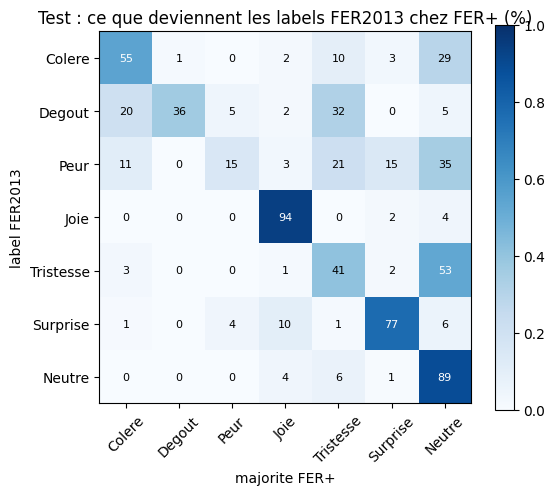

In [11]:
ok_te = yfp_te >= 0
print(f"test : {len(y_te)} images")
print(f"  majorite FER+ nette dans les 7 classes : {ok_te.sum()}")
print(f"  egalite en tete (ambigue)              : {np.sum(yfp_te == AMBIGU)}")
print(f"  mepris ou 'inconnu' majoritaire        : {np.sum(yfp_te == HORS_CLASSES)}")
print(f"  'pas un visage' majoritaire            : {np.sum(yfp_te == PAS_UN_VISAGE)}")
print(f"\nparmi les {ok_te.sum()} images exploitables, FER+ contredit le label FER2013 dans "
      f"{100 * np.mean(yfp_te[ok_te] != y_te[ok_te]):.1f} % des cas")

# d'ou viennent les desaccords : ligne = label FER2013, colonne = majorite FER+
m = confusion_matrix(y_te[ok_te], yfp_te[ok_te], labels=range(7), normalize="true")
plt.figure(figsize=(6, 5))
plt.imshow(m, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        plt.text(j, i, f"{100 * m[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white" if m[i, j] > 0.5 else "black")
plt.xticks(range(7), CLASSES, rotation=45)
plt.yticks(range(7), CLASSES)
plt.xlabel("majorite FER+")
plt.ylabel("label FER2013")
plt.title("Test : ce que deviennent les labels FER2013 chez FER+ (%)")
plt.colorbar()
plt.show()

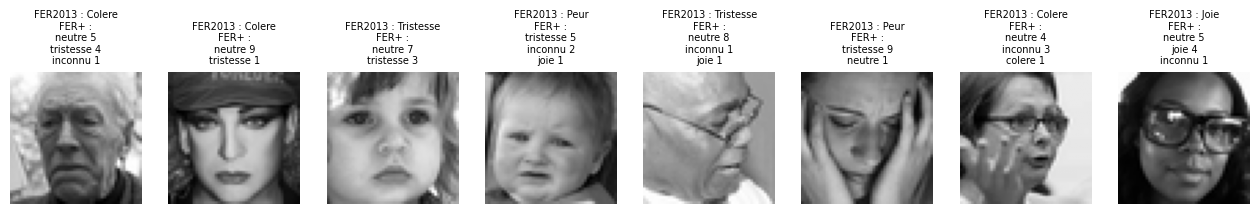

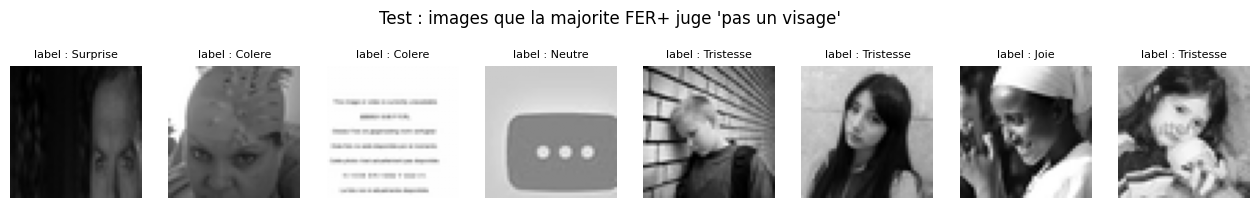

In [12]:
# quelques images ou FER+ n'est pas d'accord, avec le detail des 10 votes
desaccord = np.where(ok_te & (yfp_te != y_te))[0]
sel = np.random.default_rng(1).choice(desaccord, 8, replace=False)
noms_votes = ["neutre", "joie", "surprise", "tristesse", "colere", "degout", "peur", "mepris", "inconnu", "pas visage"]
fig, axes = plt.subplots(1, 8, figsize=(16, 3.2))
for ax, i in zip(axes, sel):
    ax.imshow(x8_te[i], cmap="gray", vmin=0, vmax=255)
    top = np.argsort(votes_te[i])[::-1][:3]
    detail = "\n".join(f"{noms_votes[t]} {votes_te[i][t]}" for t in top if votes_te[i][t] > 0)
    ax.set_title(f"FER2013 : {CLASSES[y_te[i]]}\nFER+ :\n{detail}", fontsize=7)
    ax.axis("off")
plt.show()

nv = np.where(yfp_te == PAS_UN_VISAGE)[0]
if len(nv):
    fig, axes = plt.subplots(1, min(8, len(nv)), figsize=(2 * min(8, len(nv)), 2.2))
    for ax, i in zip(np.atleast_1d(axes), nv[:8]):
        ax.imshow(x8_te[i], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"label : {CLASSES[y_te[i]]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Test : images que la majorite FER+ juge 'pas un visage'", y=1.05)
    plt.show()

L'alignement est bon : 66 % d'accord entre FER2013 et la majorité FER+, contre 18 % quand on décale d'une ligne. On peut donc comparer les deux annotations image par image.

Sur le test, la majorité FER+ contredit le label FER2013 pour 34 % des images, et la matrice montre que ce n'est pas un bruit uniforme :

- la joie (94 % d'accord), le neutre (89 %) et la surprise (77 %) sont des labels solides ;
- la peur est la classe la plus fragile : seulement 15 % des images étiquetées "peur" dans FER2013 sont vues comme de la peur par la majorité FER+, 35 % passent en neutre, 21 % en tristesse et 15 % en surprise ;
- plus de la moitié des images "tristesse" (53 %) deviennent "neutre" ;
- le dégoût se partage entre dégoût (36 %), tristesse (32 %) et colère (20 %).

Il faut lire ces chiffres avec prudence, FER+ n'est pas la vérité non plus. C'est un vote de 10 personnes, sans contexte, sur des vignettes de 48×48, et devant une expression faible "neutre" est une réponse naturelle. Mais le message reste net : pour un tiers du test, deux procédures d'annotation sérieuses ne donnent pas la même réponse. Ça fixe un plafond à ce qu'on peut attendre d'un modèle, et c'est cohérent avec l'accuracy humaine d'environ 65 % (± 5) mesurée par Goodfellow et al. (2013) sur ce dataset. On s'attend donc à ce que le modèle se trompe surtout entre peur, tristesse et neutre, et à ce qu'une partie de ces "erreurs" n'en soient pas vraiment.

## 3. Le modèle cible, et ce que vaut vraiment son score

### 3.1 Chargement ou entraînement

Si `MODEL_PATH` existe, on attaque notre modèle final. Sinon on entraîne ici un CNN de référence : trois blocs de deux convolutions 3×3 (32, 64 puis 128 filtres) avec batch normalization, max pooling et dropout, puis une couche dense de 256 neurones et la sortie softmax à 7 neurones. Augmentation légère (miroir, petits décalages, rotations et zooms), Adam, early stopping sur la loss de validation. C'est un modèle "honnête" pour FER2013, du niveau de ce qu'on obtient dans le notebook principal ; le but ici n'est pas de battre un record.

Le modèle substitut (partie 6.3) et le modèle durci (partie 8) sont construits avec la même fonction.

In [13]:
def construire_cnn(filtres=(32, 64, 128), dense=256, nom="cnn"):
    entree = keras.Input(shape=(48, 48, 1))
    h = entree
    for f in filtres:
        for _ in range(2):
            h = layers.Conv2D(f, 3, padding="same", use_bias=False)(h)
            h = layers.BatchNormalization()(h)
            h = layers.Activation("relu")(h)
        h = layers.MaxPooling2D(2)(h)
        h = layers.Dropout(0.25)(h)
    h = layers.Flatten()(h)
    h = layers.Dense(dense, use_bias=False)(h)
    h = layers.BatchNormalization()(h)
    h = layers.Activation("relu")(h)
    h = layers.Dropout(0.5)(h)
    sortie = layers.Dense(7, activation="softmax")(h)
    return keras.Model(entree, sortie, name=nom)

augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.08, 0.08, fill_mode="reflect"),
    layers.RandomRotation(0.04, fill_mode="reflect"),     # 0.04 tour = +-14 degres
    layers.RandomZoom(0.08, fill_mode="reflect"),
], name="augmentation")

def entrainer(modele, epochs):
    # l'augmentation est mise devant le modele seulement pour l'entrainement (elle tourne ainsi sur le GPU) ;
    # elle ne fait rien en prediction et le modele sauvegarde ne la contient pas
    a_entrainer = keras.Sequential([keras.Input(shape=(48, 48, 1)), augmentation, modele])
    a_entrainer.compile(optimizer=keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    rappels = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
               keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-5)]
    return a_entrainer.fit(x_tr, y_tr, batch_size=64, validation_data=(x_va, y_va), epochs=epochs,
                           callbacks=rappels, verbose=2)

def courbes(historique, titre):
    h = historique.history
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(h["loss"], label="train"); axes[0].plot(h["val_loss"], label="validation"); axes[0].set_title("loss")
    axes[1].plot(h["accuracy"], label="train"); axes[1].plot(h["val_accuracy"], label="validation"); axes[1].set_title("accuracy")
    for ax in axes:
        ax.set_xlabel("epoch"); ax.legend()
    plt.suptitle(titre)
    plt.show()

pas de modele final trouve, on entraine le CNN de reference
Epoch 1/60
449/449 - 26s - 59ms/step - accuracy: 0.2854 - loss: 1.8724 - val_accuracy: 0.3271 - val_loss: 1.6577 - learning_rate: 0.0010
Epoch 2/60
449/449 - 15s - 33ms/step - accuracy: 0.4090 - loss: 1.5396 - val_accuracy: 0.4614 - val_loss: 1.4145 - learning_rate: 0.0010
Epoch 3/60
449/449 - 15s - 33ms/step - accuracy: 0.4649 - loss: 1.3862 - val_accuracy: 0.4999 - val_loss: 1.2571 - learning_rate: 0.0010
Epoch 4/60
449/449 - 15s - 33ms/step - accuracy: 0.4954 - loss: 1.3127 - val_accuracy: 0.5194 - val_loss: 1.2542 - learning_rate: 0.0010
Epoch 5/60
449/449 - 20s - 44ms/step - accuracy: 0.5172 - loss: 1.2676 - val_accuracy: 0.5472 - val_loss: 1.1786 - learning_rate: 0.0010
Epoch 6/60
449/449 - 22s - 48ms/step - accuracy: 0.5332 - loss: 1.2293 - val_accuracy: 0.5648 - val_loss: 1.1317 - learning_rate: 0.0010
Epoch 7/60
449/449 - 18s - 39ms/step - accuracy: 0.5411 - loss: 1.1992 - val_accuracy: 0.5333 - val_loss: 1.2077 - lea

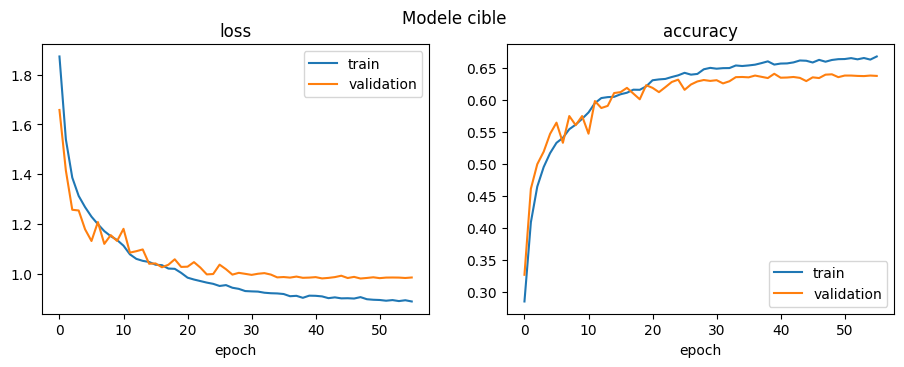

(None, 48, 48, 1) -> (None, 7) | 1,470,247 parametres


In [14]:
if os.path.exists(MODEL_PATH):
    cible = keras.models.load_model(MODEL_PATH)
    print("modele attaque : notre modele final ->", MODEL_PATH)
elif os.path.exists(fichier("cible.keras")):
    cible = keras.models.load_model(fichier("cible.keras"))
    print("modele attaque : CNN de reference deja entraine ->", fichier("cible.keras"))
else:
    print("pas de modele final trouve, on entraine le CNN de reference")
    keras.utils.set_random_seed(SEED)
    cible = construire_cnn(nom="cible")
    t0 = time.time()
    hist_cible = entrainer(cible, EPOCHS)
    print(f"entrainement : {(time.time() - t0) / 60:.1f} min")
    cible.save(fichier("cible.keras"))
    courbes(hist_cible, "Modele cible")

print(cible.input_shape, "->", cible.output_shape, "|", f"{cible.count_params():,} parametres")

### 3.2 Récupérer les logits

Le modèle se termine par un softmax. Pour les attaques et pour la calibration, on a besoin des valeurs juste avant le softmax, les logits. La raison est très concrète : quand le modèle est très sûr de lui, le softmax sature à 1,0 en float32, le gradient de la perte calculée sur les probabilités devient nul, et une attaque construite là-dessus échoue... alors que le modèle n'est pas robuste du tout. C'est un des pièges listés par Carlini et al. (2019) sous le nom de *gradient masking*.

La fonction suivante retrouve les logits quelle que soit la façon dont la dernière couche est écrite (`Dense(7, activation="softmax")` ou `Dense(7)` suivie d'une couche `Softmax`). La fonction `adapter` met nos images au format attendu par le modèle, au cas où le modèle final prendrait une autre taille ou des images en couleur (transfer learning).

In [15]:
def adapter(modele):
    _, H, W, C = modele.input_shape
    def f(x):
        if (H, W) != (48, 48):
            x = tf.image.resize(x, (H, W))
        if C == 3:
            x = tf.repeat(x, 3, axis=-1)
        return x * PIXEL_MAX
    return f

def fonction_logits(modele):
    derniere = modele.layers[-1]
    prep = adapter(modele)
    activation = getattr(getattr(derniere, "activation", None), "__name__", "")
    try:
        avant = keras.Model(modele.inputs, derniere.input)
    except Exception:
        avant = None
    if avant is not None and isinstance(derniere, layers.Dense) and activation == "softmax":
        W = derniere.kernel
        b = derniere.bias if derniere.use_bias else 0.0
        f = lambda x: tf.matmul(avant(prep(x), training=False), W) + b
    elif avant is not None and (isinstance(derniere, layers.Softmax) or activation == "softmax"):
        f = lambda x: avant(prep(x), training=False)
    else:
        print("attention : logits introuvables, on utilise log(p) (les attaques risquent d'etre sous-estimees)")
        f = lambda x: tf.math.log(modele(prep(x), training=False) + 1e-12)
    return tf.function(f, reduce_retracing=True)

def logits_de(f, x, batch=500):
    if len(x) == 0:
        return np.zeros((0, 7), "float32")
    return np.concatenate([f(tf.constant(x[i:i + batch])).numpy() for i in range(0, len(x), batch)])

def softmax(z, T=1.0):
    z = z / T
    e = np.exp(z - z.max(1, keepdims=True))
    return e / e.sum(1, keepdims=True)

f_cible = fonction_logits(cible)

# verification : softmax(logits) doit redonner exactement la sortie du modele
p_keras = cible.predict(adapter(cible)(tf.constant(x_te[:256])), verbose=0)
print("ecart max avec model.predict :", np.abs(softmax(logits_de(f_cible, x_te[:256])) - p_keras).max())

ecart max avec model.predict : 2.592802e-06


### 3.3 Mesure de base

D'abord les chiffres habituels, avec leur incertitude. On compare aussi l'accuracy sur un échantillon du train, sur la validation et sur le test : si le test était beaucoup plus proche du train que la validation, ce serait le signe que le modèle a vu des images de test pendant son entraînement (par exemple à cause d'un autre découpage dans le notebook principal).

In [16]:
def ic_bootstrap(correct, n=2000):
    rng = np.random.default_rng(0)
    moyennes = correct[rng.integers(0, len(correct), (n, len(correct)))].mean(1)
    return np.percentile(moyennes, [2.5, 97.5])

def fmt(correct):
    correct = np.asarray(correct, dtype=float)
    if len(correct) == 0:
        return "n/a (aucune image)"
    bas, haut = ic_bootstrap(correct)
    return f"{100 * correct.mean():5.1f} %  [{100 * bas:.1f} ; {100 * haut:.1f}]  (n = {len(correct)})"

z_te = logits_de(f_cible, x_te)
pred_te = z_te.argmax(1)
bon_te = pred_te == y_te

print("accuracy test     :", fmt(bon_te))
print(f"balanced accuracy : {100 * balanced_accuracy_score(y_te, pred_te):.1f} %")
print(f"macro F1          : {100 * f1_score(y_te, pred_te, average='macro'):.1f} %")
print(f"toujours 'Joie'   : {100 * np.mean(y_te == JOIE):.1f} %")

idx_tr = np.random.default_rng(SEED).choice(len(x_tr), min(len(x_tr), len(x_te)), replace=False)
print("\ncontrole de fuite / surapprentissage")
print("  train (echantillon) :", fmt(logits_de(f_cible, x_tr[idx_tr]).argmax(1) == y_tr[idx_tr]))
print("  validation          :", fmt(logits_de(f_cible, x_va).argmax(1) == y_va))
print("  test                :", fmt(bon_te))

accuracy test     :  65.9 %  [64.4 ; 67.4]  (n = 3589)
balanced accuracy : 58.9 %
macro F1          : 60.4 %
toujours 'Joie'   : 24.5 %

controle de fuite / surapprentissage
  train (echantillon) :  69.2 %  [67.7 ; 70.8]  (n = 3589)
  validation          :  64.0 %  [62.4 ; 65.6]  (n = 3589)
  test                :  65.9 %  [64.4 ; 67.4]  (n = 3589)


,n,rappel %,IC 95 %,precision %,confondue surtout avec
classe,,,,,
Colere,491,57.4,[53 ; 62],55.6,Neutre
Degout,55,25.5,[16 ; 38],82.4,Colere
Peur,528,38.6,[35 ; 43],54.4,Tristesse
Joie,879,87.8,[85 ; 90],86.6,Neutre
Tristesse,594,50.3,[46 ; 54],52.6,Neutre
Surprise,416,76.2,[72 ; 80],79.1,Peur
Neutre,626,76.4,[73 ; 80],57.6,Tristesse


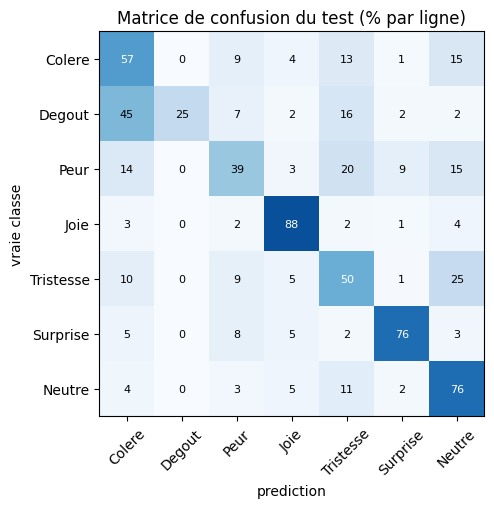

In [17]:
cm = confusion_matrix(y_te, pred_te, labels=range(7))
lignes = []
for c in range(7):
    n, k = cm[c].sum(), cm[c, c]
    ic = stats.binomtest(int(k), int(n)).proportion_ci(method="wilson")
    autres = cm[c].copy()
    autres[c] = -1
    lignes.append({"classe": CLASSES[c], "n": n, "rappel %": round(100 * k / n, 1),
                   "IC 95 %": f"[{100 * ic.low:.0f} ; {100 * ic.high:.0f}]",
                   "precision %": round(100 * k / max(cm[:, c].sum(), 1), 1),
                   "confondue surtout avec": CLASSES[autres.argmax()]})
display(pd.DataFrame(lignes).set_index("classe"))

cmn = cm / cm.sum(1, keepdims=True)
plt.figure(figsize=(6, 5))
plt.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
for i in range(7):
    for j in range(7):
        plt.text(j, i, f"{100 * cmn[i, j]:.0f}", ha="center", va="center", fontsize=8, color="white" if cmn[i, j] > 0.5 else "black")
plt.xticks(range(7), CLASSES, rotation=45)
plt.yticks(range(7), CLASSES)
plt.xlabel("prediction")
plt.ylabel("vraie classe")
plt.title("Matrice de confusion du test (% par ligne)")
plt.show()

### 3.4 Ce que vaut vraiment ce score

On reprend les résultats de la partie 2 pour corriger le chiffre brut, de deux façons.

1. **Doublons.** On compare l'accuracy sur les images de test qui ont un quasi-doublon dans le train et sur les autres. Si le modèle a mémorisé ces images, il doit faire nettement mieux dessus. On donne aussi le score sur le test débarrassé de ses doublons : c'est le chiffre honnête.
2. **Labels.** On re-score le modèle avec la majorité FER+ au lieu du label FER2013, sur les images où FER+ a une majorité nette. On regarde surtout les erreurs : dans combien de cas le modèle "se trompe" alors que la majorité des 10 annotateurs FER+ dit la même chose que lui ?

In [18]:
print("1) doublons")
print("   test avec un quasi-doublon dans le train :", fmt(bon_te[quasi_te]))
print("   test sans doublon                        :", fmt(bon_te[~quasi_te]))
if quasi_te.sum() > 0:
    tableau = [[bon_te[quasi_te].sum(), (~bon_te[quasi_te]).sum()], [bon_te[~quasi_te].sum(), (~bon_te[~quasi_te]).sum()]]
    print(f"   test exact de Fisher : p = {stats.fisher_exact(tableau)[1]:.2g}")
    print(f"   sur les doublons, le modele predit le label de l'image du train dans "
          f"{100 * np.mean(pred_te[quasi_te] == y_tr[voisin_te][quasi_te]):.1f} % des cas")
ecart_doublons = 100 * (bon_te.mean() - bon_te[~quasi_te].mean())
print(f"   -> le score brut surestime l'accuracy 'hors doublons' de {ecart_doublons:+.2f} point(s)")

print("\n2) labels")
print("   accuracy avec les labels FER2013 :", fmt(bon_te[ok_te]))
print("   accuracy avec la majorite FER+   :", fmt((pred_te == yfp_te)[ok_te]))
accord = ok_te & (yfp_te == y_te)
print("   images ou FER2013 et FER+ sont d'accord :", fmt(bon_te[accord]))
erreurs = ok_te & ~bon_te
part_fausses_erreurs = np.mean(pred_te[erreurs] == yfp_te[erreurs])
print(f"   parmi les {erreurs.sum()} erreurs, le modele dit la meme chose que la majorite FER+ dans "
      f"{100 * part_fausses_erreurs:.1f} % des cas")

1) doublons
   test avec un quasi-doublon dans le train :  75.3 %  [71.4 ; 79.1]  (n = 465)
   test sans doublon                        :  64.5 %  [62.8 ; 66.3]  (n = 3124)
   test exact de Fisher : p = 3.7e-06
   sur les doublons, le modele predit le label de l'image du train dans 77.4 % des cas
   -> le score brut surestime l'accuracy 'hors doublons' de +1.39 point(s)

2) labels
   accuracy avec les labels FER2013 :  67.3 %  [65.7 ; 68.9]  (n = 3350)
   accuracy avec la majorite FER+   :  70.0 %  [68.4 ; 71.5]  (n = 3350)
   images ou FER2013 et FER+ sont d'accord :  84.7 %  [83.2 ; 86.2]  (n = 2196)
   parmi les 1096 erreurs, le modele dit la meme chose que la majorite FER+ dans 44.2 % des cas


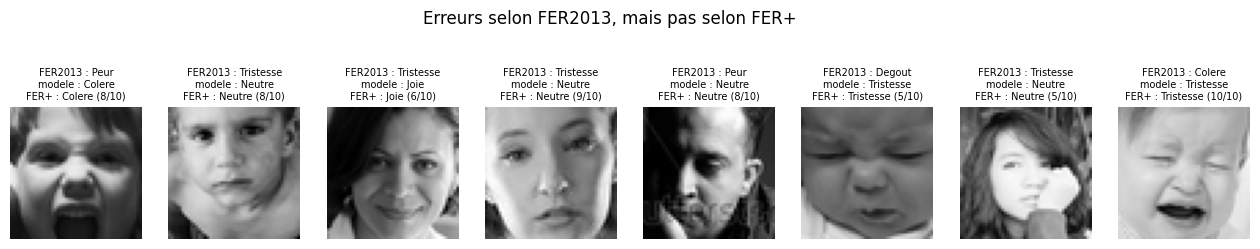

In [19]:
# des "erreurs" ou le modele est d'accord avec FER+ contre FER2013
sel = np.where(erreurs & (pred_te == yfp_te))[0]
sel = np.random.default_rng(2).choice(sel, min(8, len(sel)), replace=False)
if len(sel):
    fig, axes = plt.subplots(1, len(sel), figsize=(2 * len(sel), 2.8))
    for ax, i in zip(np.atleast_1d(axes), sel):
        ax.imshow(x_te[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"FER2013 : {CLASSES[y_te[i]]}\nmodele : {CLASSES[pred_te[i]]}\nFER+ : {CLASSES[yfp_te[i]]} ({votes_te[i].max()}/10)", fontsize=7)
        ax.axis("off")
    plt.suptitle("Erreurs selon FER2013, mais pas selon FER+", y=1.08)
    plt.show()

**Lecture.** Les doublons comptent. Sur les 465 images de test qui ont un quasi-doublon dans le train, le modèle fait 75,3 % contre 64,5 % sur les autres (Fisher, p = 4·10⁻⁶), et dans 77 % des cas il redonne le label de l'image du train : il a en partie mémorisé ces images. L'effet sur le score global reste modeste (+1,4 point), parce que les doublons ne font que 13 % du test. Le chiffre honnête est donc 64,5 % [62,8 ; 66,3].

Le bruit d'annotation pèse beaucoup plus lourd. Noté avec la majorité FER+ au lieu du label FER2013, le modèle passe de 67,3 % à 70,0 % sur les mêmes images, et il fait 84,7 % là où les deux annotations sont d'accord. Surtout, dans 44 % de ses erreurs, la majorité des 10 annotateurs FER+ dit la même chose que lui (H2 confirmée). Les exemples ci-dessus le montrent : beaucoup de « peurs » ou de « tristesses » mal classées sont des visages que la plupart des gens jugent neutres. Une bonne part de l'écart entre 66 % et 100 % ne vient pas du modèle mais des labels.

### 3.5 Calibration

Dans le pipeline final, on affiche une probabilité à côté de chaque visage. Encore faut-il que ce chiffre veuille dire quelque chose : un modèle bien calibré qui annonce 70 % doit avoir raison environ 7 fois sur 10.

On mesure l'écart avec l'ECE (*expected calibration error*, Guo et al., 2017) : on range les prédictions en 15 tranches de confiance et on fait la moyenne pondérée de l'écart entre confiance annoncée et accuracy réelle dans chaque tranche. Puis on applique la correction la plus simple, le *temperature scaling* : on divise les logits par une température T choisie sur la validation (jamais sur le test). Ça ne change aucune prédiction, seulement les probabilités.

temperature choisie sur la validation : T = 1.21
ECE test avant : 2.19 %   apres : 3.57 %
NLL test avant : 0.941    apres : 0.936
confiance moyenne 67.1 % pour une accuracy de 65.9 %


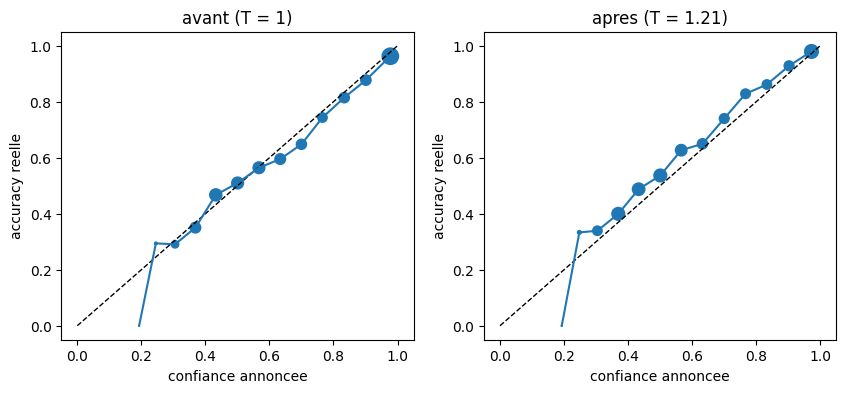

In [20]:
def ece(p, y, nb=15):
    conf, pred = p.max(1), p.argmax(1)
    bords = np.linspace(0, 1, nb + 1)
    total = 0.0
    for a, b in zip(bords[:-1], bords[1:]):
        dans = (conf > a) & (conf <= b)
        if dans.any():
            total += dans.mean() * abs((pred[dans] == y[dans]).mean() - conf[dans].mean())
    return total

def nll(z, y, T):
    return -np.mean(np.log(softmax(z, T)[np.arange(len(y)), y] + 1e-12))

def temperature(f):
    z_va = logits_de(f, x_va)
    return minimize_scalar(lambda t: nll(z_va, y_va, t), bounds=(0.05, 10), method="bounded").x

def diagramme_fiabilite(p, y, ax, titre, nb=15):
    conf, bon = p.max(1), p.argmax(1) == y
    bords = np.linspace(0, 1, nb + 1)
    centres, accs, poids = [], [], []
    for a, b in zip(bords[:-1], bords[1:]):
        dans = (conf > a) & (conf <= b)
        if dans.sum() > 0:
            centres.append(conf[dans].mean()); accs.append(bon[dans].mean()); poids.append(dans.sum())
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    ax.scatter(centres, accs, s=np.array(poids) / 5)
    ax.plot(centres, accs)
    ax.set_xlabel("confiance annoncee"); ax.set_ylabel("accuracy reelle"); ax.set_title(titre)

T_cible = temperature(f_cible)
p_brut, p_cal = softmax(z_te), softmax(z_te, T_cible)
print(f"temperature choisie sur la validation : T = {T_cible:.2f}")
print(f"ECE test avant : {100 * ece(p_brut, y_te):.2f} %   apres : {100 * ece(p_cal, y_te):.2f} %")
print(f"NLL test avant : {nll(z_te, y_te, 1):.3f}    apres : {nll(z_te, y_te, T_cible):.3f}")
print(f"confiance moyenne {100 * p_brut.max(1).mean():.1f} % pour une accuracy de {100 * bon_te.mean():.1f} %")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
diagramme_fiabilite(p_brut, y_te, axes[0], "avant (T = 1)")
diagramme_fiabilite(p_cal, y_te, axes[1], f"apres (T = {T_cible:.2f})")
plt.show()

**Lecture.** Contrairement à ce qu'on attendait (H3), le modèle n'est pas sur-confiant : il annonce en moyenne 67,1 % pour 65,9 % de bonnes réponses, et l'ECE n'est que de 2,2 %. La température choisie sur la validation (T = 1,21) améliore un peu la log-vraisemblance du test (0,941 → 0,936) mais fait monter l'ECE (2,2 % → 3,6 %). Ce n'est pas contradictoire : la température optimise la log-vraisemblance sur la validation, pas l'ECE, et sur un modèle déjà bien calibré il ne reste presque rien à corriger ; un écart d'un point d'ECE est de l'ordre du bruit de mesure avec 15 tranches et 3 589 images.

Le dropout, la batch normalization, l'augmentation et l'arrêt sur la loss de validation expliquent sans doute cette bonne calibration. En pratique, les pourcentages affichés dans la démo peuvent être pris à peu près au pied de la lettre, tant que les images ressemblent à celles de FER2013 (la partie 4 montre ce qui se passe sinon).

## 4. Conditions réelles dégradées

Ici il n'y a pas d'attaquant : on simule ce qui arrive aux images entre la caméra et le CNN. On applique huit dégradations, chacune à 5 niveaux d'intensité, à toutes les images du test, et on regarde l'accuracy. L'idée vient d'ImageNet-C (Hendrycks et Dietterich, 2019), adaptée à notre cas :

- **bruit** : capteur de webcam en faible lumière ;
- **flou** : mise au point ratée, mouvement ;
- **sous-exposition** : pièce sombre (pixels multipliés par un facteur inférieur à 1) ;
- **contraste faible** : contre-jour, écran ou caméra de mauvaise qualité ;
- **JPEG** : compression d'une vidéo ou d'une photo passée par une messagerie ;
- **basse résolution** : visage loin de la caméra, la boîte YOLO fait 15 pixels de large et on l'agrandit en 48×48 ;
- **cadrage** : la boîte de YOLO n'est jamais centrée et dimensionnée comme les recadrages de FER2013, donc on décale et on redimensionne la boîte au hasard (les bords sont complétés par effet miroir, c'est une approximation) ;
- **rotation** : tête penchée.

Après chaque dégradation, l'image est arrondie sur 256 niveaux de gris, comme une vraie image 8 bits. Pour la sous-exposition ça compte : une photo sombre perd vraiment des nuances.

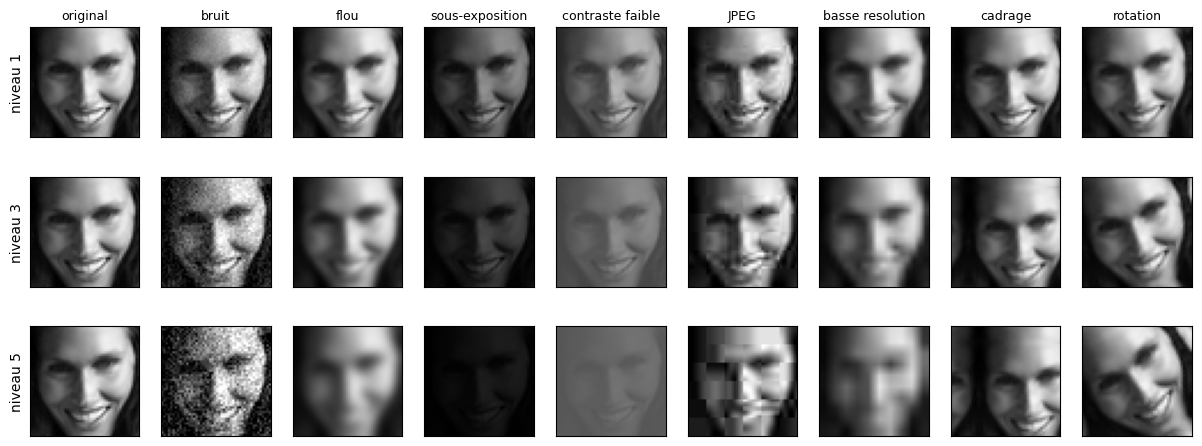

In [21]:
def quantifier(x):
    return (np.round(np.clip(x, 0, 1) * 255) / 255).astype("float32")

def bruit(x, s, rng):
    return x + rng.normal(0, [0.02, 0.04, 0.06, 0.09, 0.12][s - 1], x.shape)

def flou(x, s, rng):
    sigma = [0.5, 0.8, 1.1, 1.5, 2.0][s - 1]
    return ndimage.gaussian_filter(x, sigma=(0, sigma, sigma, 0))

def sous_exposition(x, s, rng):
    return x * [0.6, 0.45, 0.3, 0.2, 0.12][s - 1]

def contraste(x, s, rng):
    c = [0.6, 0.45, 0.3, 0.2, 0.12][s - 1]
    m = x.mean(axis=(1, 2, 3), keepdims=True)
    return (x - m) * c + m

def jpeg(x, s, rng):
    q = [40, 25, 15, 10, 6][s - 1]
    sortie = np.empty_like(x)
    for i, im in enumerate(x):
        buf = io.BytesIO()
        Image.fromarray((im[:, :, 0] * 255).round().astype("uint8")).save(buf, "JPEG", quality=q)
        sortie[i, :, :, 0] = np.array(Image.open(buf), dtype="float32") / 255
    return sortie

def basse_resolution(x, s, rng):
    r = [32, 24, 18, 14, 10][s - 1]
    petit = tf.image.resize(x, (r, r), method="area")
    return tf.image.resize(petit, (48, 48), method="bilinear").numpy()

def cadrage(x, s, rng):
    # boite de detection imprecise : decalage et changement d'echelle aleatoires (jusqu'a +-a)
    a = [0.05, 0.10, 0.15, 0.20, 0.25][s - 1]
    n, pad = len(x), 24
    xp = np.pad(x, ((0, 0), (pad, pad), (pad, pad), (0, 0)), mode="reflect")
    cote = 48 + 2 * pad - 1
    demi = 23.5 * (1 + rng.uniform(-a, a, n))
    cy = pad + 23.5 + 48 * rng.uniform(-a, a, n)
    cx = pad + 23.5 + 48 * rng.uniform(-a, a, n)
    boites = np.stack([cy - demi, cx - demi, cy + demi, cx + demi], axis=1) / cote
    return tf.image.crop_and_resize(xp, boites.astype("float32"), np.arange(n, dtype="int32"), (48, 48)).numpy()

def rotation(x, s, rng):
    angle = [5, 10, 15, 20, 30][s - 1]
    signes = rng.choice([-1, 1], len(x))
    return np.stack([ndimage.rotate(im, sg * angle, reshape=False, mode="reflect", order=1) for im, sg in zip(x, signes)])

CORRUPTIONS = {"bruit": bruit, "flou": flou, "sous-exposition": sous_exposition, "contraste faible": contraste,
               "JPEG": jpeg, "basse resolution": basse_resolution, "cadrage": cadrage, "rotation": rotation}

# a quoi ressemblent les niveaux 1, 3 et 5
visage = x_te[[7]]
fig, axes = plt.subplots(3, len(CORRUPTIONS) + 1, figsize=(15, 5.5))
for r, s in enumerate([1, 3, 5]):
    axes[r, 0].imshow(visage[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[r, 0].set_ylabel(f"niveau {s}")
    for c, (nom, fn) in enumerate(CORRUPTIONS.items(), start=1):
        axes[r, c].imshow(quantifier(fn(visage, s, np.random.default_rng(0)))[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
        if r == 0:
            axes[r, c].set_title(nom, fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_title("original", fontsize=9)
plt.show()

(26 s)  accuracy sans degradation : 65.9 %


,niv. 1,niv. 2,niv. 3,niv. 4,niv. 5,perte au niv. 3,perte au niv. 5
bruit,53.5,35.6,24.3,18.5,18.3,41.6,47.6
JPEG,55.1,50.2,46.3,42.9,35.8,19.7,30.1
basse resolution,65.6,59.9,47.3,36.8,26.7,18.7,39.3
sous-exposition,63.8,62.1,59.3,56.8,48.5,6.6,17.4
contraste faible,64.8,63.4,60.2,57.2,47.6,5.7,18.4
flou,66.8,66.9,62.0,47.3,33.0,3.9,32.9
cadrage,66.3,65.3,63.2,60.0,55.5,2.7,10.4
rotation,66.7,65.5,64.6,63.7,57.7,1.4,8.2


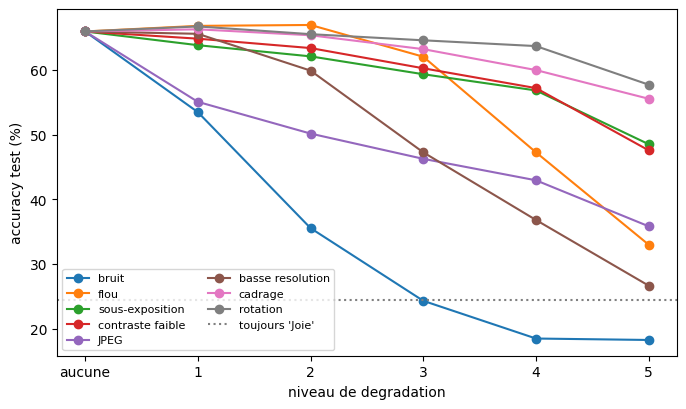

In [22]:
def suite_corruptions(f):
    res = {}
    for nom, fn in CORRUPTIONS.items():
        rng = np.random.default_rng(SEED)   # memes perturbations pour tous les modeles
        res[nom] = [100 * np.mean(logits_de(f, quantifier(fn(x_te, s, rng))).argmax(1) == y_te) for s in range(1, 6)]
    return pd.DataFrame(res, index=[f"niv. {s}" for s in range(1, 6)]).T

t0 = time.time()
corr_cible = suite_corruptions(f_cible)
acc_propre = 100 * bon_te.mean()
print(f"({time.time() - t0:.0f} s)  accuracy sans degradation : {acc_propre:.1f} %")
tableau_corr = corr_cible.round(1)
tableau_corr["perte au niv. 3"] = (acc_propre - corr_cible["niv. 3"]).round(1)
tableau_corr["perte au niv. 5"] = (acc_propre - corr_cible["niv. 5"]).round(1)
display(tableau_corr.sort_values("perte au niv. 3", ascending=False))

plt.figure(figsize=(8, 4.5))
for nom, ligne in corr_cible.iterrows():
    plt.plot(range(6), [acc_propre] + list(ligne), marker="o", label=nom)
plt.axhline(100 * np.mean(y_te == JOIE), color="gray", ls=":", label="toujours 'Joie'")
plt.xticks(range(6), ["aucune"] + [f"{s}" for s in range(1, 6)])
plt.xlabel("niveau de degradation"); plt.ylabel("accuracy test (%)")
plt.legend(fontsize=8, ncol=2)
plt.show()

Deux tests de plus, qui collent au pipeline final.

**Scénario webcam.** Les dégradations ne viennent jamais seules. On combine un cadrage imprécis, une résolution un peu faible et un peu de bruit, chacun au niveau 2, ce qui correspond à peu près à une webcam d'ordinateur portable dans une pièce normalement éclairée avec une personne à un ou deux mètres.

**Cohérence miroir.** Une expression ne change pas quand on retourne la photo horizontalement. Si la prédiction change entre une image et son miroir, le modèle est instable sur cette image. Le modèle a pourtant été entraîné avec des retournements aléatoires, donc on s'attend à un taux faible.

In [23]:
def scenario_webcam(f):
    rng = np.random.default_rng(SEED)
    x = quantifier(bruit(basse_resolution(cadrage(x_te, 2, rng), 2, rng), 2, rng))
    return 100 * np.mean(logits_de(f, x).argmax(1) == y_te)

def incoherence_miroir(f):
    a = logits_de(f, x_te).argmax(1)
    b = logits_de(f, x_te[:, :, ::-1]).argmax(1)
    return 100 * np.mean(a != b)

webcam_cible = scenario_webcam(f_cible)
miroir_cible = incoherence_miroir(f_cible)
print(f"scenario webcam   : {webcam_cible:.1f} %  (au lieu de {acc_propre:.1f} %)")
print(f"incoherence miroir : la prediction change pour {miroir_cible:.1f} % des images")

scenario webcam   : 17.8 %  (au lieu de 65.9 %)
incoherence miroir : la prediction change pour 14.0 % des images


**Lecture.** Le classement des dégradations n'est pas celui qu'on attendait (H4 est fausse). Le **bruit** est de loin le pire : dès le niveau 2 (écart-type 0,04, une dizaine de niveaux de gris), l'accuracy tombe à 35,6 %, et au niveau 3 à 24,3 %, le score d'un modèle qui répondrait toujours « Joie ». Le JPEG et la basse résolution suivent (−19 à −20 points au niveau 3). À l'inverse, le cadrage (−2,7) et la rotation (−1,4) coûtent peu, sans doute parce que l'augmentation de l'entraînement contenait déjà des décalages, des zooms et des rotations : le modèle est robuste à ce qu'on lui a montré, et fragile au reste. Le flou léger ne coûte rien (66,8 % au niveau 1), mais l'accuracy s'effondre à partir du niveau 4.

Le **scénario webcam** est le résultat le plus grave du notebook : en combinant trois dégradations modérées (niveau 2), on tombe à 17,8 %, sous le niveau de « toujours Joie ». Chaque dégradation seule était supportable ; ensemble, elles se cumulent. C'est exactement ce que verra le modèle pendant une démonstration, d'où l'expérience E5 du notebook principal.

Enfin, la prédiction change pour 14 % des images quand on les retourne en miroir, alors que le modèle a été entraîné avec des miroirs aléatoires. Ce sont les images où il hésite entre deux classes : un petit changement le fait basculer. En vidéo, un lissage des probabilités sur plusieurs images atténue ce clignotement.

## 5. Occlusions : ce que le modèle regarde

Avec le port du masque, les lunettes de soleil ou une main devant la bouche, une partie du visage manque souvent. On cache quatre zones et on regarde le rappel de chaque classe. Les zones sont placées sur le visage moyen du train : les visages de FER2013 sont à peu près alignés, mais pas parfaitement, donc ces zones sont approximatives. Le masque est un simple rectangle clair, une vraie forme de masque ferait sans doute un peu mieux.

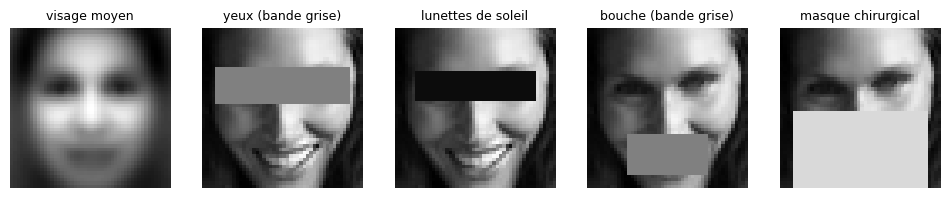

In [24]:
ZONES = {
    "yeux (bande grise)": dict(lignes=(12, 23), colonnes=(4, 44), valeur=0.5),
    "lunettes de soleil": dict(lignes=(13, 22), colonnes=(6, 42), valeur=0.05),
    "bouche (bande grise)": dict(lignes=(32, 44), colonnes=(12, 36), valeur=0.5),
    "masque chirurgical": dict(lignes=(25, 48), colonnes=(4, 44), valeur=0.85),
}

def occulter(x, zone):
    x = x.copy()
    (a, b), (c, d) = zone["lignes"], zone["colonnes"]
    x[:, a:b, c:d, :] = zone["valeur"]
    return x

visage_moyen = x_tr.mean(0)
fig, axes = plt.subplots(1, len(ZONES) + 1, figsize=(12, 2.8))
axes[0].imshow(visage_moyen[:, :, 0], cmap="gray")
axes[0].set_title("visage moyen", fontsize=9)
for ax, (nom, z) in zip(axes[1:], ZONES.items()):
    ax.imshow(occulter(x_te[[7]], z)[0, :, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(nom, fontsize=9)
for ax in axes:
    ax.axis("off")
plt.show()

In [25]:
def rappels_occlusion(f):
    def rappels(x):
        p = logits_de(f, x).argmax(1)
        return [100 * np.mean(p[y_te == c] == c) for c in range(7)] + [100 * np.mean(p == y_te)]
    res = {"aucune": rappels(x_te)}
    for nom, z in ZONES.items():
        res[nom] = rappels(occulter(x_te, z))
    return pd.DataFrame(res, index=CLASSES + ["TOUTES (accuracy)"])

occ_cible = rappels_occlusion(f_cible)
display(occ_cible.round(1).style.background_gradient(cmap="RdYlGn", vmin=0, vmax=100, axis=None).format("{:.0f}"))

,aucune,yeux (bande grise),lunettes de soleil,bouche (bande grise),masque chirurgical
Colere,57,42,34,42,34
Degout,26,2,4,9,0
Peur,39,10,5,29,14
Joie,88,84,81,61,0
Tristesse,50,6,3,34,2
Surprise,76,64,35,64,82
Neutre,76,86,94,66,67
TOUTES (accuracy),66,51,46,50,28


Le tableau dit ce qui casse, pas pourquoi. Pour voir où le modèle regarde, on fait une carte de sensibilité par occlusion (Zeiler et Fergus, 2014) : on fait glisser un carré gris de 8×8 pixels sur l'image et on mesure à chaque position de combien baisse la probabilité de la bonne classe. On fait la moyenne sur 40 images bien classées par classe. Contrairement à Grad-CAM, cette méthode n'a besoin d'aucune hypothèse sur l'architecture, donc elle marche aussi bien avec notre modèle final qu'avec le CNN de référence.

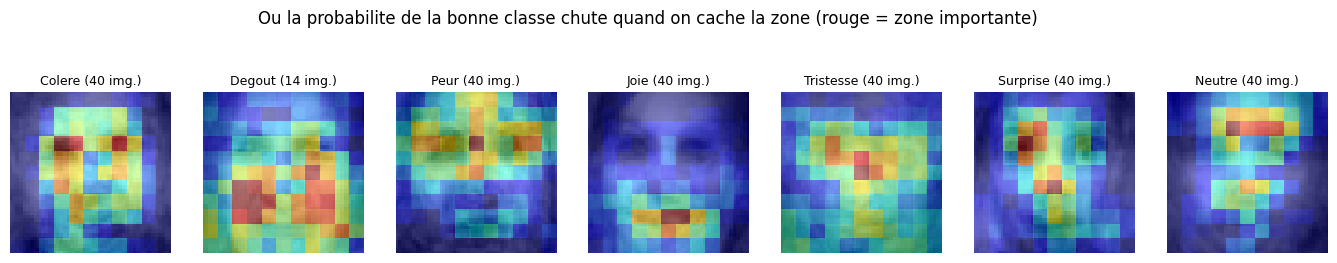

In [26]:
def carte_sensibilite(f, x, classe, taille=8, pas=4):
    positions = list(range(0, 48 - taille + 1, pas))
    base = softmax(logits_de(f, x))[:, classe]
    carte = np.zeros((len(positions), len(positions)))
    for a, i in enumerate(positions):
        for b, j in enumerate(positions):
            xo = x.copy()
            xo[:, i:i + taille, j:j + taille, :] = 0.5
            carte[a, b] = np.mean(base - softmax(logits_de(f, xo))[:, classe])
    return carte

fig, axes = plt.subplots(1, 7, figsize=(17, 3))
for c, ax in enumerate(axes):
    bien = np.where((y_te == c) & bon_te)[0][:40]
    ax.axis("off")
    if len(bien) == 0:   # possible pour le degout, qui n'a que 55 images de test
        ax.set_title(f"{CLASSES[c]} : aucune image\nbien classee", fontsize=9)
        continue
    carte = carte_sensibilite(f_cible, x_te[bien], c)
    ax.imshow(x_te[bien].mean(0)[:, :, 0], cmap="gray")
    ax.imshow(carte, cmap="jet", alpha=0.5, extent=(2, 46, 46, 2), vmin=0)
    ax.set_title(f"{CLASSES[c]} ({len(bien)} img.)", fontsize=9)
plt.suptitle("Ou la probabilite de la bonne classe chute quand on cache la zone (rouge = zone importante)", y=1.04)
plt.show()

**Lecture.** Le tableau confirme H5 de façon spectaculaire : avec un masque chirurgical, le rappel de la joie passe de 88 % à **0 %**, et une simple bande grise sur la bouche le fait déjà tomber à 61 %. La joie est reconnue par le sourire, et presque uniquement par lui. La tristesse et la peur dépendent au contraire du haut du visage : avec une bande sur les yeux, la tristesse passe de 50 % à 6 % et la peur de 39 % à 10 %. Le neutre profite de toutes les occlusions (jusqu'à 94 % avec des lunettes de soleil) : quand l'information manque, le modèle se replie sur « Neutre », ce qui est un comportement plutôt raisonnable. La surprise résiste au masque (82 %) : les sourcils levés et les yeux écarquillés suffisent.

Les cartes de sensibilité disent la même chose et rassurent sur un point : les zones importantes sont toutes **sur le visage** (la bouche pour la joie, les sourcils et les yeux pour la colère, la surprise et le neutre, le bas du visage pour le dégoût), jamais sur les bords de l'image. Rien n'indique que le modèle a appris les filigranes ou le fond à la place de l'expression.

## 6. Attaques adversariales

On passe aux attaques délibérées. Une image adversariale est une image modifiée très légèrement, chaque pixel bougeant d'au plus ε, pour que le modèle se trompe. On donne ε sur l'échelle 0-255 : ε = 2/255 veut dire que chaque pixel bouge d'au plus 2 niveaux de gris, ce qui est invisible.

Deux attaques classiques :

- **FGSM** (Goodfellow et al., 2015) : un seul pas, x' = x + ε · signe(∇ₓ perte). Rapide, mais faible.
- **PGD** (Madry et al., 2018) : la même idée répétée 20 fois avec un pas plus petit, en revenant à chaque fois dans la boule ‖x' − x‖∞ ≤ ε, et en partant d'un point aléatoire de cette boule. C'est la référence pour mesurer la robustesse d'un modèle.

À la fin, les images adversariales sont arrondies sur 256 niveaux, comme si l'attaquant devait envoyer un vrai fichier PNG. Une perturbation qui ne survit pas à cet arrondi ne compte pas. Les attaques tournent sur les `N_EVAL` images de test tirées une fois pour toutes.

### 6.1 Boîte blanche, attaque non ciblée

In [27]:
idx_eval = np.random.default_rng(SEED).choice(len(x_te), N_EVAL, replace=False)
xe, ye = x_te[idx_eval], y_te[idx_eval]

def fabrique_gradient(f):
    @tf.function(reduce_retracing=True)
    def grad(x, y):
        with tf.GradientTape() as tape:
            tape.watch(x)
            perte = tf.nn.sparse_softmax_cross_entropy_with_logits(labels=y, logits=f(x))
        return tape.gradient(perte, x)   # perte par image : le gradient de chaque image ne depend que d'elle
    return grad

def fgsm(grad, x, y, eps):
    return quantifier(x + eps * np.sign(grad(tf.constant(x), tf.constant(y)).numpy()))

def pgd(grad, x, y, eps, nb_pas=20, classe_visee=None, graine=0):
    alpha = 2.5 * eps / nb_pas
    x0 = tf.constant(x)
    depart = np.random.default_rng(graine).uniform(-eps, eps, x.shape).astype("float32")
    x_adv = tf.clip_by_value(x0 + depart, 0, 1)
    for _ in range(nb_pas):
        if classe_visee is None:
            pas = alpha * tf.sign(grad(x_adv, tf.constant(y)))                # on fait monter la perte de la vraie classe
        else:
            pas = -alpha * tf.sign(grad(x_adv, tf.constant(classe_visee)))    # on fait descendre celle de la classe visee
        x_adv = tf.clip_by_value(tf.clip_by_value(x_adv + pas, x0 - eps, x0 + eps), 0, 1)
    return quantifier(x_adv.numpy())

def bruit_signe(x, eps, graine=0):
    # temoin : meme amplitude que l'attaque, mais direction au hasard
    return quantifier(x + eps * np.random.default_rng(graine).choice([-1.0, 1.0], x.shape))

def par_lots(fn, x, y, batch=250):
    return np.concatenate([fn(x[i:i + batch], y[i:i + batch]) for i in range(0, len(x), batch)])

def predit(f, x):
    return logits_de(f, x).argmax(1)

EPS = [1, 2, 4, 8]   # en niveaux de gris, eps = e / 255

def balayage(f, grad):
    res = {"bruit aleatoire": [], "FGSM": [], "PGD-20": []}
    for e in EPS:
        eps = e / 255
        res["bruit aleatoire"].append(100 * np.mean(predit(f, bruit_signe(xe, eps)) == ye))
        res["FGSM"].append(100 * np.mean(predit(f, par_lots(lambda a, b: fgsm(grad, a, b, eps), xe, ye)) == ye))
        res["PGD-20"].append(100 * np.mean(predit(f, par_lots(lambda a, b: pgd(grad, a, b, eps), xe, ye)) == ye))
    df = pd.DataFrame(res, index=[f"eps = {e}/255" for e in EPS]).T
    df.insert(0, "sans attaque", 100 * np.mean(predit(f, xe) == ye))
    return df

grad_cible = fabrique_gradient(f_cible)
t0 = time.time()
adv_cible = balayage(f_cible, grad_cible)
print(f"({time.time() - t0:.0f} s)")
display(adv_cible.round(1))

(17 s)


,sans attaque,eps = 1/255,eps = 2/255,eps = 4/255,eps = 8/255
bruit aleatoire,66.3,65.3,62.3,57.1,44.7
FGSM,66.3,22.5,11.2,7.0,8.0
PGD-20,66.3,12.6,1.6,0.0,0.0


**Contrôles.** Avant de croire un chiffre de robustesse, on vérifie que l'attaque fait bien son travail (liste inspirée de Carlini et al., 2019, et Athalye et al., 2018) :

1. PGD doit faire au moins aussi mal que FGSM, puisqu'il fait la même chose en mieux ;
2. avec un ε énorme (32/255) l'accuracy doit tomber à presque zéro, sinon l'attaque est cassée ;
3. passer de 20 à 100 itérations ne doit pas faire remonter l'accuracy ;
4. un bruit aléatoire de même amplitude doit faire beaucoup moins de dégâts que l'attaque ;
5. les gradients ne doivent pas être nuls (sinon on serait en plein *gradient masking*).

In [28]:
def controles_attaque(f, grad, tableau):
    sous = slice(0, min(300, len(xe)))
    eps1 = EPS[0] / 255
    acc = lambda x, y: 100 * np.mean(predit(f, x) == y)
    resultats = []
    ok = all(tableau.loc["PGD-20"].iloc[1:] <= tableau.loc["FGSM"].iloc[1:] + 1)
    resultats.append(("PGD <= FGSM pour chaque eps", ok, ""))
    a32 = acc(par_lots(lambda a, b: pgd(grad, a, b, 32 / 255), xe[sous], ye[sous]), ye[sous])
    resultats.append(("eps = 32/255 -> accuracy proche de 0", a32 < 2, f"{a32:.1f} %"))
    a20 = acc(par_lots(lambda a, b: pgd(grad, a, b, eps1, nb_pas=20), xe[sous], ye[sous]), ye[sous])
    a100 = acc(par_lots(lambda a, b: pgd(grad, a, b, eps1, nb_pas=100), xe[sous], ye[sous]), ye[sous])
    resultats.append((f"PGD-100 <= PGD-20 (eps = {EPS[0]}/255)", a100 <= a20 + 1, f"{a20:.1f} % -> {a100:.1f} %"))
    propre = tableau["sans attaque"].iloc[0]
    ecart_bruit = propre - tableau.loc["bruit aleatoire"].iloc[-1]
    ecart_fgsm = propre - tableau.loc["FGSM"].iloc[-1]
    resultats.append(("bruit aleatoire bien moins nocif que FGSM", ecart_bruit < ecart_fgsm / 3,
                      f"-{ecart_bruit:.1f} pts contre -{ecart_fgsm:.1f} pts"))
    g = grad(tf.constant(xe[sous]), tf.constant(ye[sous])).numpy()
    nuls = np.mean(np.abs(g).reshape(len(g), -1).max(1) == 0)
    resultats.append(("gradients non nuls", nuls < 0.01, f"{100 * nuls:.1f} % d'images a gradient nul"))
    for texte, ok, detail in resultats:
        print(f"[{'OK' if ok else 'A VERIFIER'}] {texte}  {detail}")

controles_attaque(f_cible, grad_cible, adv_cible)

[OK] PGD <= FGSM pour chaque eps  
[OK] eps = 32/255 -> accuracy proche de 0  0.0 %
[OK] PGD-100 <= PGD-20 (eps = 1/255)  13.3 % -> 13.3 %
[A VERIFIER] bruit aleatoire bien moins nocif que FGSM  -21.6 pts contre -58.3 pts
[OK] gradients non nuls  0.0 % d'images a gradient nul


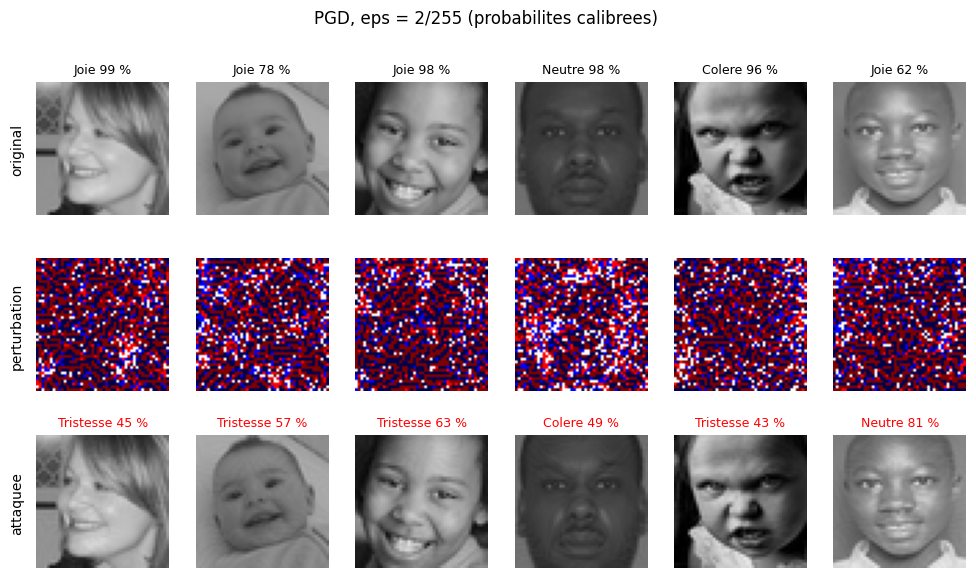

In [29]:
# a quoi ressemble une attaque a 2/255
sel = np.where(predit(f_cible, xe) == ye)[0][:6]
x_adv = pgd(grad_cible, xe[sel], ye[sel], 2 / 255)
p0, p1 = softmax(logits_de(f_cible, xe[sel]), T_cible), softmax(logits_de(f_cible, x_adv), T_cible)
fig, axes = plt.subplots(3, 6, figsize=(12, 6.5))
for k in range(6):
    axes[0, k].imshow(xe[sel][k, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, k].set_title(f"{CLASSES[p0[k].argmax()]} {100 * p0[k].max():.0f} %", fontsize=9)
    axes[1, k].imshow((x_adv[k] - xe[sel][k])[:, :, 0], cmap="seismic", vmin=-2 / 255, vmax=2 / 255)
    axes[2, k].imshow(x_adv[k, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[2, k].set_title(f"{CLASSES[p1[k].argmax()]} {100 * p1[k].max():.0f} %", fontsize=9, color="red")
for ax in axes.ravel():
    ax.axis("off")
axes[0, 0].text(-10, 24, "original", rotation=90, va="center")
axes[1, 0].text(-10, 24, "perturbation", rotation=90, va="center")
axes[2, 0].text(-10, 24, "attaquee", rotation=90, va="center")
plt.suptitle("PGD, eps = 2/255 (probabilites calibrees)")
plt.show()

**Lecture.** Sans défense, le modèle n'a aucune robustesse adversariale (H6 confirmée). PGD à ε = 2/255, où chaque pixel change d'au plus 2 niveaux de gris, ce qui est invisible, fait tomber l'accuracy de 66,3 % à 1,6 %, et à 0 % dès 4/255. FGSM, en un seul pas, est déjà à 11,2 % à 2/255. Le témoin, un bruit aléatoire de même amplitude, ne coûte que 4 points à 2/255 : ce n'est pas la quantité de perturbation qui compte, c'est sa direction, donnée par le gradient.

Un contrôle est marqué « à vérifier » : à ε = 8/255, le bruit aléatoire coûte 21,6 points, alors que le critère demandait moins d'un tiers de la perte FGSM (58,3 / 3 = 19,4). Ce n'est pas un défaut de l'attaque. Un bruit de ±8/255 a un écart-type d'environ 0,03, et la partie 4 a montré que ce modèle est très sensible au bruit ; aux ε plus petits, l'écart est net (−4 points pour le bruit contre −55 pour FGSM à 2/255). Les autres contrôles passent (PGD plus fort que FGSM, accuracy nulle à 32/255, rien de gagné en passant de 20 à 100 itérations, gradients non nuls) : l'attaque est correctement codée et il n'y a pas de masquage de gradient.

L'attaque ciblée est la plus inquiétante pour un usage réel : à 2/255, on fait dire « Joie » au modèle sur 94 % des visages, et « Colère » sur 96 %. Quelqu'un qui contrôle le fichier image choisit la réponse.

### 6.2 Attaque ciblée

Faire se tromper le modèle, c'est une chose. Lui faire dire *ce qu'on veut* en est une autre, et c'est le scénario qui pose vraiment problème si le système sert à prendre des décisions. On teste deux cibles : faire passer n'importe quel visage pour joyeux (quelqu'un qui veut paraître satisfait), et faire passer n'importe quel visage pour en colère (quelqu'un qui veut faire signaler une autre personne). Le taux de réussite est calculé sur les images dont la vraie classe n'est pas la cible.

In [30]:
def attaque_ciblee(f, grad, classe):
    garde = ye != classe
    x, y = xe[garde], ye[garde]
    taux = {}
    for e in EPS:
        cibles = np.full(len(x), classe, dtype="int32")
        x_adv = np.concatenate([pgd(grad, x[i:i + 250], y[i:i + 250], e / 255, classe_visee=cibles[i:i + 250])
                                for i in range(0, len(x), 250)])
        taux[f"eps = {e}/255"] = 100 * np.mean(predit(f, x_adv) == classe)
    taux_base = 100 * np.mean(predit(f, x) == classe)
    return pd.Series({"sans attaque": taux_base, **taux})

ciblee_cible = pd.DataFrame({f"-> {CLASSES[c]}": attaque_ciblee(f_cible, grad_cible, c) for c in [JOIE, COLERE]}).T
display(ciblee_cible.round(1))

,sans attaque,eps = 1/255,eps = 2/255,eps = 4/255,eps = 8/255
-> Joie,3.6,61.4,94.1,99.9,100.0
-> Colere,6.7,66.7,96.2,100.0,100.0


### 6.3 Boîte noire : attaque par transfert

Un attaquant réaliste n'a pas nos poids. Mais FER2013 est public : il peut entraîner son propre modèle dessus, fabriquer ses images adversariales sur ce modèle substitut et espérer qu'elles trompent aussi le nôtre (Papernot et al., 2017). On joue son rôle avec un CNN plus petit (24, 48, 96 filtres, dense de 128), une autre graine, et rien de notre modèle.

Le substitut utilise un PGD simple. Des techniques conçues pour mieux transférer existent (par exemple MI-FGSM, Dong et al., 2018), donc nos chiffres sont plutôt une borne basse de ce qu'un attaquant motivé obtiendrait.

In [31]:
if os.path.exists(fichier("substitut.keras")):
    substitut = keras.models.load_model(fichier("substitut.keras"))
else:
    keras.utils.set_random_seed(SEED + 1)
    substitut = construire_cnn(filtres=(24, 48, 96), dense=128, nom="substitut")
    t0 = time.time()
    hist_sub = entrainer(substitut, EPOCHS)
    print(f"entrainement : {(time.time() - t0) / 60:.1f} min")
    substitut.save(fichier("substitut.keras"))

f_sub = fonction_logits(substitut)
grad_sub = fabrique_gradient(f_sub)
print("substitut, accuracy test :", fmt(predit(f_sub, x_te) == y_te))

# les images adversariales ne dependent que du substitut : on les garde pour la partie 8
adv_sub = {e: par_lots(lambda a, b: pgd(grad_sub, a, b, e / 255, nb_pas=40), xe, ye) for e in [2, 4, 8]}

def transfert(f):
    propre = predit(f, xe) == ye
    lignes = {}
    for e, x_adv in adv_sub.items():
        trompe_sub = predit(f_sub, x_adv) != ye
        apres = predit(f, x_adv) == ye
        temoin = predit(f, bruit_signe(xe, e / 255)) == ye
        lignes[f"eps = {e}/255"] = {
            "accuracy sous transfert %": 100 * apres.mean(),
            "temoin bruit %": 100 * temoin.mean(),
            "taux de transfert %": 100 * np.mean(~apres[propre & trompe_sub]),
        }
    return pd.DataFrame(lignes).T

print("accuracy du modele cible sans attaque :", f"{100 * np.mean(predit(f_cible, xe) == ye):.1f} %")
transfert_cible = transfert(f_cible)
display(transfert_cible.round(1))

Epoch 1/60
449/449 - 19s - 41ms/step - accuracy: 0.2679 - loss: 1.8942 - val_accuracy: 0.3285 - val_loss: 1.6577 - learning_rate: 0.0010
Epoch 2/60
449/449 - 12s - 27ms/step - accuracy: 0.3710 - loss: 1.6182 - val_accuracy: 0.3873 - val_loss: 1.6447 - learning_rate: 0.0010
Epoch 3/60
449/449 - 12s - 28ms/step - accuracy: 0.4335 - loss: 1.4727 - val_accuracy: 0.4739 - val_loss: 1.3551 - learning_rate: 0.0010
Epoch 4/60
449/449 - 13s - 28ms/step - accuracy: 0.4653 - loss: 1.3925 - val_accuracy: 0.4901 - val_loss: 1.3254 - learning_rate: 0.0010
Epoch 5/60
449/449 - 12s - 28ms/step - accuracy: 0.4843 - loss: 1.3391 - val_accuracy: 0.4865 - val_loss: 1.2963 - learning_rate: 0.0010
Epoch 6/60
449/449 - 12s - 28ms/step - accuracy: 0.5034 - loss: 1.3045 - val_accuracy: 0.5272 - val_loss: 1.2075 - learning_rate: 0.0010
Epoch 7/60
449/449 - 12s - 27ms/step - accuracy: 0.5219 - loss: 1.2637 - val_accuracy: 0.5269 - val_loss: 1.2260 - learning_rate: 0.0010
Epoch 8/60
449/449 - 12s - 28ms/step - ac

,accuracy sous transfert %,temoin bruit %,taux de transfert %
eps = 2/255,20.5,62.3,70.1
eps = 4/255,4.8,57.1,92.8
eps = 8/255,0.5,44.7,99.2


Le taux de transfert se lit ainsi : parmi les images que notre modèle classait bien et que l'attaque a réussi à faire rater au substitut, quelle proportion fait aussi rater notre modèle.

**Lecture.** Les attaques se transfèrent très bien (H7 confirmée). Le substitut est plus petit (63,5 % sur le test), entraîné avec une autre graine, et l'attaquant ne connaît rien de notre modèle. Pourtant, à 4/255, notre modèle tombe à 4,8 %, contre 57,1 % avec un bruit de même amplitude, et 93 % des images qui trompent le substitut trompent aussi notre modèle (70 % dès 2/255). Deux réseaux entraînés sur les mêmes données apprennent des frontières de décision très proches. Comme FER2013 est public, ce scénario ne demande aucun accès privilégié : c'est pour ça qu'il est classé « élevé » et non « moyen » dans la grille de gravité.

### 6.4 Patch adversarial universel

Les attaques précédentes modifient tous les pixels du fichier image, ce qui suppose que l'attaquant ait la main sur ce fichier. Quelqu'un devant la caméra ne peut modifier que ce qu'il porte. On cherche donc un patch universel (Brown et al., 2017) : un carré de 10×10 pixels (4 % de l'image) qui, posé sur le front de n'importe qui, pousse le modèle vers une classe choisie, ici la joie.

Le patch est optimisé sur des images du **train** uniquement, à des positions tirées au hasard sur le front pour qu'il ne dépende pas d'un placement au pixel près. On l'évalue ensuite sur le test, avec deux témoins de même taille aux mêmes positions : un patch de bruit aléatoire et un patch gris uni.

Limite importante : c'est une version numérique. On ne l'imprime pas, il n'y a ni éclairage, ni perspective, ni imprimante. Un vrai autocollant demanderait d'optimiser aussi sur ces transformations (*Expectation over Transformation*, Athalye et al., 2018). Le résultat est donc plutôt une borne haute de ce qu'on obtiendrait avec un patch réel.

In [32]:
TAILLE_PATCH = 10
LIGNES_FRONT = (0, 3)       # ligne du coin haut-gauche tiree dans [0, 3[ : le patch reste au-dessus des sourcils
COLONNES_FRONT = (14, 25)   # colonne du coin haut-gauche tiree dans [14, 25[ : a peu pres centre

def coller(x, patch, i, j):
    p = TAILLE_PATCH
    pads = [[0, 0], [i, 48 - p - i], [j, 48 - p - j], [0, 0]]
    toile = tf.pad(patch[None], pads)
    masque = tf.pad(tf.ones((1, p, p, 1)), pads)
    return x * (1 - masque) + toile * masque

def optimiser_patch(f, classe, nb_pas=PAS_PATCH, graine=SEED):
    rng = np.random.default_rng(graine)
    source = x_tr[y_tr != classe]
    theta = tf.Variable(tf.zeros((TAILLE_PATCH, TAILLE_PATCH, 1)))   # patch = sigmoid(theta), toujours dans [0, 1]
    opt = keras.optimizers.Adam(0.1)
    cibles = tf.fill([128], classe)
    for _ in range(nb_pas):
        lot = tf.constant(source[rng.integers(0, len(source), 128)])
        i, j = int(rng.integers(*LIGNES_FRONT)), int(rng.integers(*COLONNES_FRONT))
        with tf.GradientTape() as tape:
            logits = f(coller(lot, tf.sigmoid(theta), i, j))
            perte = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(labels=cibles, logits=logits))
        opt.apply_gradients([(tape.gradient(perte, theta), theta)])
    return quantifier(tf.sigmoid(theta).numpy())

def coller_np(x, patch, positions):
    x = x.copy()
    for k, (i, j) in enumerate(positions):
        x[k, i:i + TAILLE_PATCH, j:j + TAILLE_PATCH, :] = patch
    return x

def evaluer_patch(f, patch, classe):
    garde = y_te != classe
    x = x_te[garde]
    rng = np.random.default_rng(SEED)
    positions = [(rng.integers(*LIGNES_FRONT), rng.integers(*COLONNES_FRONT)) for _ in range(len(x))]
    temoins = {"patch optimise": patch,
               "temoin : bruit": quantifier(rng.uniform(0, 1, patch.shape)),
               "temoin : gris uni": np.full(patch.shape, 0.5, "float32")}
    res = {"sans patch": 100 * np.mean(predit(f, x) == classe)}
    for nom, p in temoins.items():
        res[nom] = 100 * np.mean(predit(f, coller_np(x, p, positions)) == classe)
    return pd.Series(res, name=f"% de visages non joyeux classes '{CLASSES[classe]}'")

t0 = time.time()
patch_cible = optimiser_patch(f_cible, JOIE)
print(f"({time.time() - t0:.0f} s)")
res_patch_cible = evaluer_patch(f_cible, patch_cible, JOIE)
display(res_patch_cible.round(1).to_frame())

(27 s)


,% de visages non joyeux classes 'Joie'
sans patch,4.4
patch optimise,19.4
temoin : bruit,6.1
temoin : gris uni,5.3


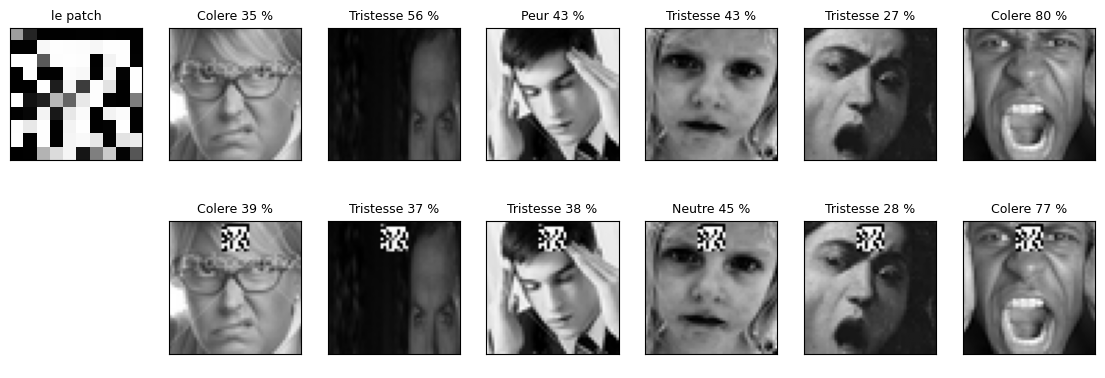

In [33]:
exemples = np.where((y_te != JOIE))[0][:6]
avec = coller_np(x_te[exemples], patch_cible, [(1, 19)] * len(exemples))
p_avant, p_apres = softmax(logits_de(f_cible, x_te[exemples]), T_cible), softmax(logits_de(f_cible, avec), T_cible)
fig, axes = plt.subplots(2, 7, figsize=(14, 4.6))
axes[0, 0].imshow(patch_cible[:, :, 0], cmap="gray", vmin=0, vmax=1); axes[0, 0].set_title("le patch", fontsize=9)
axes[1, 0].axis("off")
for k in range(6):
    axes[0, k + 1].imshow(x_te[exemples][k, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[0, k + 1].set_title(f"{CLASSES[p_avant[k].argmax()]} {100 * p_avant[k].max():.0f} %", fontsize=9)
    axes[1, k + 1].imshow(avec[k, :, :, 0], cmap="gray", vmin=0, vmax=1)
    axes[1, k + 1].set_title(f"{CLASSES[p_apres[k].argmax()]} {100 * p_apres[k].max():.0f} %", fontsize=9)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.show()

**Lecture.** Le patch universel marche, mais bien moins que les attaques sur tous les pixels. Posé sur le front, il fait passer 19,4 % des visages non joyeux pour joyeux, contre 4,4 % sans patch et 6,1 % avec un patch de bruit de même taille. L'effet est réel (trois fois le témoin) mais limité, et les exemples montrent qu'il fait surtout basculer des visages déjà ambigus. Un carré de 4 % de l'image, sur une zone (le front) que le modèle regarde peu d'après les cartes de la partie 5, a peu de prise. Et c'est une borne haute : un vrai autocollant imprimé, filmé sous un autre éclairage et un autre angle, ferait moins bien.

## 7. Images qui ne sont pas des visages

Dans le pipeline final, le CNN ne choisit pas ses entrées : il reçoit tout ce que YOLO a pris pour un visage. Or un softmax produit toujours une distribution sur les 7 classes, même pour la photo d'un mur. La question est donc : est-ce que le modèle se trahit, avec une confiance plus faible, quand l'image n'est pas un visage ? Si oui, on peut ajouter un seuil de rejet dans le pipeline.

Jeux d'images hors distribution utilisés (1000 images chacun, sauf le dernier) :

- bruit uniforme, et images unies d'un seul niveau de gris ;
- chiffres MNIST et photos CIFAR-10 (avions, voitures, animaux...) passés en 48×48 niveaux de gris ;
- nos visages de test retournés tête en bas : ce sont bien des visages, mais dans une position jamais vue ;
- les images de validation et de test de FER2013 que la majorité FER+ juge "pas un visage".

Deux scores de "normalité" : la probabilité maximale après calibration (MSP, Hendrycks et Gimpel, 2017) et l'énergie, c'est-à-dire le logsumexp des logits (Liu et al., 2020). L'AUROC mesure à quel point le score sépare les vrais visages des autres (1 = parfait, 0,5 = hasard). Le seuil de rejet est fixé sur la **validation**, de façon à garder 95 % des vrais visages, puis appliqué tel quel au reste.

In [34]:
from scipy.special import logsumexp

n_ood = 1000
(_, _), (mnist_x, _) = keras.datasets.mnist.load_data()
# CIFAR-10 depuis un miroir Hugging Face fige (le certificat du serveur d'origine a expire)
CIFAR = ("https://huggingface.co/datasets/uoft-cs/cifar10/resolve/"
         "0b2714987fa478483af9968de7c934580d0bb9a2/plain_text/test-00000-of-00001.parquet")
df_cifar = pd.read_parquet(telecharger(CIFAR, "cifar10_test.parquet")).iloc[:n_ood]
cifar_gris = np.stack([np.array(Image.open(io.BytesIO(d["bytes"])).convert("L")) for d in df_cifar["img"]])
rng = np.random.default_rng(SEED)
OOD = {
    "bruit uniforme": rng.uniform(0, 1, (n_ood, 48, 48, 1)),
    "image unie": np.ones((n_ood, 48, 48, 1)) * rng.uniform(0, 1, (n_ood, 1, 1, 1)),
    "MNIST": tf.image.resize(mnist_x[:n_ood, :, :, None].astype("float32") / 255, (48, 48)).numpy(),
    "CIFAR-10": tf.image.resize(cifar_gris[..., None].astype("float32") / 255, (48, 48)).numpy(),
    "visages a l'envers": xe[:, ::-1],
    "'pas un visage' (FER+)": np.concatenate([x_va[yfp_va == PAS_UN_VISAGE], x_te[yfp_te == PAS_UN_VISAGE]]),
}
OOD = {k: quantifier(v) for k, v in OOD.items()}

def analyse_ood(f, T):
    msp = lambda z: softmax(z, T).max(1)
    z_va, z_id = logits_de(f, x_va), logits_de(f, x_te)
    seuil = np.quantile(msp(z_va), 0.05)
    lignes = []
    for nom, xo in OOD.items():
        zo = logits_de(f, xo)
        etiq = np.r_[np.ones(len(z_id)), np.zeros(len(zo))]
        lignes.append({
            "jeu": nom, "n": len(xo),
            "confiance moyenne %": 100 * msp(zo).mean(),
            "AUROC MSP": roc_auc_score(etiq, np.r_[msp(z_id), msp(zo)]),
            "AUROC energie": roc_auc_score(etiq, np.r_[logsumexp(z_id, 1), logsumexp(zo, 1)]),
            "acceptees au seuil %": 100 * np.mean(msp(zo) >= seuil),
            "classe la plus predite": CLASSES[np.bincount(zo.argmax(1), minlength=7).argmax()],
        })
    print(f"seuil de rejet (fixe sur la validation) : confiance >= {100 * seuil:.1f} %")
    print(f"vrais visages du test acceptes : {100 * np.mean(msp(z_id) >= seuil):.1f} %  "
          f"(confiance moyenne {100 * msp(z_id).mean():.1f} %)")
    return pd.DataFrame(lignes).set_index("jeu")

ood_cible = analyse_ood(f_cible, T_cible)
display(ood_cible.round(3))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
seuil de rejet (fixe sur la validation) : confiance >= 31.6 %
vrais visages du test acceptes : 94.9 %  (confiance moyenne 62.4 %)


,n,confiance moyenne %,AUROC MSP,AUROC energie,acceptees au seuil %,classe la plus predite
jeu,,,,,,
bruit uniforme,1000,59.641,0.493,0.384,100.000,Tristesse
image unie,1000,39.597,0.810,0.908,86.200,Neutre
MNIST,1000,54.989,0.575,0.579,98.300,Tristesse
CIFAR-10,1000,44.663,0.735,0.748,87.600,Tristesse
visages a l'envers,1000,43.252,0.755,0.748,85.400,Tristesse
'pas un visage' (FER+),27,47.899,0.685,0.766,81.481,Tristesse


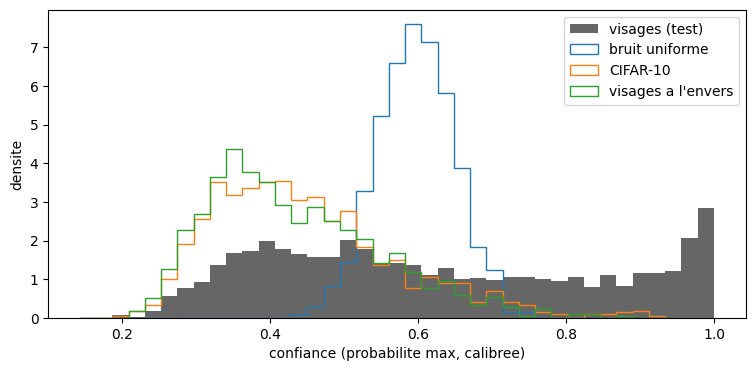

In [35]:
z_id = logits_de(f_cible, x_te)
plt.figure(figsize=(9, 4))
bins = np.linspace(1 / 7, 1, 40)
plt.hist(softmax(z_id, T_cible).max(1), bins=bins, density=True, alpha=0.6, label="visages (test)", color="black")
for nom in ["bruit uniforme", "CIFAR-10", "visages a l'envers"]:
    plt.hist(softmax(logits_de(f_cible, OOD[nom]), T_cible).max(1), bins=bins, density=True, histtype="step", lw=2, label=nom)
plt.xlabel("confiance (probabilite max, calibree)"); plt.ylabel("densite")
plt.legend()
plt.show()

**Lecture.** H8 est confirmée : le modèle ne sait pas dire qu'une image n'est pas un visage. Le seuil de rejet fixé sur la validation pour garder 95 % des vrais visages est très bas (31,6 % de confiance), parce que beaucoup de vrais visages sont eux-mêmes ambigus. Il laisse donc passer 100 % du bruit uniforme, 98 % des chiffres MNIST, 88 % des photos CIFAR-10 et 81 % des images que FER+ juge « pas un visage ». Le bruit uniforme est même classé avec plus d'assurance (60 % en moyenne) que bien des vrais visages, et presque tout ce qui n'est pas un visage finit en « Tristesse ». L'énergie ne fait guère mieux que la probabilité maximale (AUROC de 0,75 contre 0,73 sur CIFAR-10).

L'histogramme montre pourquoi : les non-visages tombent dans la même plage de confiance que les visages difficiles. Conséquence pour le pipeline : on ne peut pas compter sur le CNN pour rejeter un faux positif de YOLO. Le filtre doit être le score de confiance du détecteur, qui a été entraîné, lui, à distinguer un visage de tout le reste.

## 8. Contre-mesures, puis nouveau passage de la red team

On joue maintenant l'équipe bleue. Deux défenses, choisies parce qu'elles visent ce qu'on vient de mesurer et qu'elles tiennent dans le budget d'un Colab gratuit :

1. **Augmentation "conditions réelles".** En plus de l'augmentation habituelle, on applique pendant l'entraînement des variations de luminosité et de contraste, du bruit, de la basse résolution, et un cadrage plus agressif (décalages jusqu'à 15 %, zoom jusqu'à 25 %). Pour ne pas tricher, une partie des dégradations de la partie 4 n'est jamais vue à l'entraînement : le flou, le JPEG et les occlusions. Si le modèle progresse aussi sur celles-là, c'est une vraie généralisation et pas un apprentissage du test. (Le flou ressemble quand même un peu à la basse résolution, ce n'est donc pas un test complètement indépendant ; le JPEG et les occlusions le sont davantage.)
2. **Entraînement adversarial rapide** (Wong, Rice et Kolter, 2020). À chaque lot, on fabrique des exemples adversariaux avec un pas de FGSM partant d'un point aléatoire (ε = 2/255), puis on met à jour les poids sur le mélange images normales + images attaquées. C'est bien moins cher que l'entraînement avec PGD de Madry et al., et suffisant pour de petits ε. Le modèle est choisi sur la validation avec un score qui moyenne l'accuracy normale et l'accuracy sous PGD, pour éviter le surapprentissage robuste décrit par Rice et al. (2020).

Le modèle durci a la même architecture que la cible (copie par `clone_model`, poids réinitialisés), sauf si la cible est trop grosse pour être réentraînée ici.

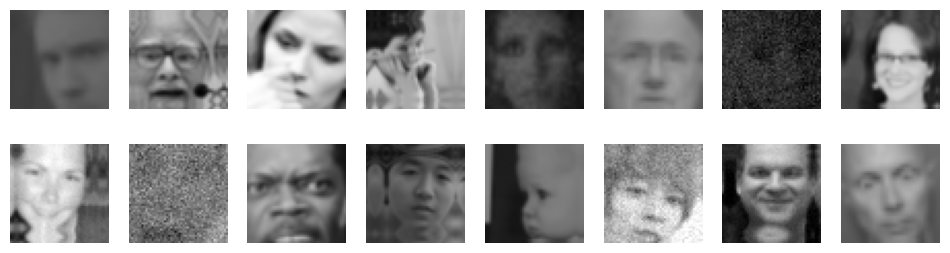

In [36]:
EPS_AT = 2 / 255
ALPHA_AT = 1.25 * EPS_AT   # pas recommande par Wong et al. (2020)

augmentation_durcie = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomTranslation(0.15, 0.15, fill_mode="reflect"),
    layers.RandomRotation(0.04, fill_mode="reflect"),
    layers.RandomZoom((-0.25, 0.25), fill_mode="reflect"),
], name="augmentation_durcie")

def degrader(x):
    n = tf.shape(x)[0]
    def tirage(p):   # 1 pour environ une proportion p des images du lot, 0 sinon
        return tf.cast(tf.random.uniform([n, 1, 1, 1]) < p, tf.float32)
    # luminosite et contraste
    m = tf.reduce_mean(x, axis=[1, 2, 3], keepdims=True)
    c = tf.random.uniform([n, 1, 1, 1], 0.3, 1.0)
    l = tf.random.uniform([n, 1, 1, 1], 0.25, 1.1)
    k = tirage(0.5)
    x = k * ((x - m) * c + m) * l + (1 - k) * x
    # bruit
    k = tirage(0.3)
    x = x + k * tf.random.normal(tf.shape(x)) * tf.random.uniform([n, 1, 1, 1], 0, 0.1)
    # basse resolution
    r = tf.random.uniform([], 12, 40, dtype=tf.int32)
    basse = tf.image.resize(tf.image.resize(x, tf.stack([r, r]), method="area"), [48, 48])
    k = tirage(0.3)
    x = k * basse + (1 - k) * x
    return tf.clip_by_value(x, 0, 1)

# apercu de ce que voit le modele durci pendant l'entrainement
apercu = degrader(augmentation_durcie(tf.constant(x_tr[:16]), training=True)).numpy()
fig, axes = plt.subplots(2, 8, figsize=(12, 3.2))
for ax, im in zip(axes.ravel(), apercu):
    ax.imshow(im[:, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
plt.show()

In [37]:
def entrainer_durci(durci, epochs):
    prep = adapter(durci)
    f_d = fonction_logits(durci)
    grad_d = fabrique_gradient(f_d)
    opt = keras.optimizers.Adam(1e-3)
    opt.build(durci.trainable_variables)
    perte_fn = keras.losses.SparseCategoricalCrossentropy()

    @tf.function
    def pas_entrainement(x, y):
        x = degrader(augmentation_durcie(x, training=True))
        # 1) exemple adversarial : un pas de FGSM depuis un point aleatoire de la boule
        delta = tf.random.uniform(tf.shape(x), -EPS_AT, EPS_AT)
        with tf.GradientTape() as tape:
            tape.watch(delta)
            perte_adv = tf.reduce_mean(tf.nn.sparse_softmax_cross_entropy_with_logits(
                labels=y, logits=f_d(tf.clip_by_value(x + delta, 0, 1))))
        delta = tf.clip_by_value(delta + ALPHA_AT * tf.sign(tape.gradient(perte_adv, delta)), -EPS_AT, EPS_AT)
        x_adv = tf.clip_by_value(x + delta, 0, 1)
        # 2) mise a jour des poids sur images normales + images attaquees
        xx, yy = tf.concat([x, x_adv], 0), tf.concat([y, y], 0)
        with tf.GradientTape() as tape:
            perte = perte_fn(yy, durci(prep(xx), training=True))
            if durci.losses:
                perte += tf.add_n(durci.losses)
        grads = tape.gradient(perte, durci.trainable_variables)
        opt.apply_gradients(zip(grads, durci.trainable_variables))
        return perte

    ds = tf.data.Dataset.from_tensor_slices((x_tr, y_tr)).shuffle(len(x_tr), seed=SEED).batch(64).prefetch(tf.data.AUTOTUNE)
    idx_v = np.random.default_rng(SEED).choice(len(x_va), 200 if RAPIDE else 500, replace=False)
    meilleur, meilleurs_poids, attente, lr = -1.0, None, 0, 1e-3
    for epoch in range(epochs):
        t0 = time.time()
        pertes = [pas_entrainement(a, b) for a, b in ds]
        acc_v = np.mean(predit(f_d, x_va) == y_va)
        rob_v = np.mean(predit(f_d, pgd(grad_d, x_va[idx_v], y_va[idx_v], EPS_AT, nb_pas=10)) == y_va[idx_v])
        score = (acc_v + rob_v) / 2
        print(f"epoch {epoch + 1:2d}  perte {np.mean([p.numpy() for p in pertes]):.3f}  "
              f"val {100 * acc_v:.1f} %  val PGD-10 {100 * rob_v:.1f} %  ({time.time() - t0:.0f} s)")
        if score > meilleur:
            meilleur, meilleurs_poids, attente = score, durci.get_weights(), 0
        else:
            attente += 1
            if attente % 3 == 0:
                lr /= 2
                opt.learning_rate.assign(lr)
            if attente >= 8:
                break
    durci.set_weights(meilleurs_poids)

if os.path.exists(fichier("durci.keras")):
    durci = keras.models.load_model(fichier("durci.keras"))
    print("modele durci deja entraine ->", fichier("durci.keras"))
else:
    keras.utils.set_random_seed(SEED + 2)
    if cible.count_params() <= 5_000_000:
        durci = keras.models.clone_model(cible)
        print("modele durci : meme architecture que la cible, poids reinitialises")
    else:
        durci = construire_cnn(nom="durci")
        print("cible trop grosse pour l'entrainement adversarial ici : on durcit le CNN de reference")
    t0 = time.time()
    entrainer_durci(durci, EPOCHS_DURCI)
    print(f"entrainement : {(time.time() - t0) / 60:.1f} min")
    durci.save(fichier("durci.keras"))

modele durci : meme architecture que la cible, poids reinitialises
epoch  1  perte 1.978  val 29.9 %  val PGD-10 27.2 %  (37 s)
epoch  2  perte 1.838  val 31.6 %  val PGD-10 28.4 %  (30 s)
epoch  3  perte 1.799  val 35.9 %  val PGD-10 29.6 %  (30 s)
epoch  4  perte 1.773  val 35.9 %  val PGD-10 30.0 %  (30 s)
epoch  5  perte 1.754  val 38.7 %  val PGD-10 32.0 %  (30 s)
epoch  6  perte 1.730  val 40.5 %  val PGD-10 33.2 %  (30 s)
epoch  7  perte 1.713  val 43.8 %  val PGD-10 33.2 %  (30 s)
epoch  8  perte 1.689  val 48.4 %  val PGD-10 34.6 %  (30 s)
epoch  9  perte 1.667  val 48.2 %  val PGD-10 38.0 %  (30 s)
epoch 10  perte 1.660  val 48.9 %  val PGD-10 37.8 %  (30 s)
epoch 11  perte 1.644  val 49.6 %  val PGD-10 36.0 %  (30 s)
epoch 12  perte 1.632  val 45.3 %  val PGD-10 31.0 %  (30 s)
epoch 13  perte 1.619  val 52.0 %  val PGD-10 38.2 %  (30 s)
epoch 14  perte 1.613  val 48.9 %  val PGD-10 34.0 %  (30 s)
epoch 15  perte 1.604  val 53.3 %  val PGD-10 41.0 %  (30 s)
epoch 16  perte 1.

### Nouveau passage de la red team

On relance tout sur le modèle durci, avec les mêmes images et les mêmes perturbations. Toutes les attaques sont recalculées contre lui (attaques adaptatives), y compris le patch qui est réoptimisé. Seules les images du substitut restent les mêmes, et c'est normal : l'attaquant boîte noire ne connaît pas notre modèle.

On commence par le test qui compte le plus : est-ce que le modèle durci est moins bon sur des images normales ? On compare les deux modèles image par image avec un test de McNemar (on ne regarde que les images où les deux modèles ne sont pas d'accord).

In [38]:
f_durci = fonction_logits(durci)
grad_durci = fabrique_gradient(f_durci)
T_durci = temperature(f_durci)
z_durci = logits_de(f_durci, x_te)
bon_durci = z_durci.argmax(1) == y_te

print("accuracy test, cible :", fmt(bon_te))
print("accuracy test, durci :", fmt(bon_durci))
b, c = int(np.sum(bon_te & ~bon_durci)), int(np.sum(~bon_te & bon_durci))
print(f"McNemar : {b} images bien classees seulement par la cible, {c} seulement par le modele durci, "
      f"p = {stats.binomtest(min(b, c), b + c).pvalue:.3g}")
print(f"balanced accuracy : {100 * balanced_accuracy_score(y_te, pred_te):.1f} % -> "
      f"{100 * balanced_accuracy_score(y_te, z_durci.argmax(1)):.1f} %")

accuracy test, cible :  65.9 %  [64.4 ; 67.4]  (n = 3589)
accuracy test, durci :  58.2 %  [56.6 ; 59.8]  (n = 3589)
McNemar : 518 images bien classees seulement par la cible, 242 seulement par le modele durci, p = 6.21e-24
balanced accuracy : 58.9 % -> 49.8 %


In [39]:
t0 = time.time()
corr_durci = suite_corruptions(f_durci)
webcam_durci, miroir_durci = scenario_webcam(f_durci), incoherence_miroir(f_durci)
occ_durci = rappels_occlusion(f_durci)
adv_durci = balayage(f_durci, grad_durci)
print("controles de l'attaque sur le modele durci :")
controles_attaque(f_durci, grad_durci, adv_durci)
ciblee_durci = pd.DataFrame({f"-> {CLASSES[c]}": attaque_ciblee(f_durci, grad_durci, c) for c in [JOIE, COLERE]}).T
transfert_durci = transfert(f_durci)
patch_durci = optimiser_patch(f_durci, JOIE)
res_patch_durci = evaluer_patch(f_durci, patch_durci, JOIE)
ood_durci = analyse_ood(f_durci, T_durci)
print(f"({(time.time() - t0) / 60:.1f} min)")

controles de l'attaque sur le modele durci :
[OK] PGD <= FGSM pour chaque eps  
[OK] eps = 32/255 -> accuracy proche de 0  0.0 %
[OK] PGD-100 <= PGD-20 (eps = 1/255)  55.7 % -> 55.7 %
[OK] bruit aleatoire bien moins nocif que FGSM  -0.1 pts contre -42.1 pts
[OK] gradients non nuls  0.0 % d'images a gradient nul
seuil de rejet (fixe sur la validation) : confiance >= 27.4 %
vrais visages du test acceptes : 94.9 %  (confiance moyenne 56.1 %)
(1.7 min)


Les contrôles de l'attaque sont encore plus importants ici que pour la cible : un entraînement adversarial mal fait peut produire un modèle qui "cache" ses gradients sans être robuste. Si tous les contrôles passent, les gains mesurés ci-dessous sont réels.

In [40]:
VUES = ["bruit", "sous-exposition", "contraste faible", "basse resolution", "cadrage"]
NON_VUES = ["flou", "JPEG"]
acc_durci = 100 * bon_durci.mean()

def resume(acc, ece_cal, corr, webcam, miroir, occ, adv, ciblee, transf, patch, ood):
    return {
        "accuracy test (%)": acc,
        "ECE apres calibration (%)": ece_cal,
        "degradations vues a l'entrainement, niv. 3 (%)": corr.loc[VUES, "niv. 3"].mean(),
        "degradations jamais vues (flou, JPEG), niv. 3 (%)": corr.loc[NON_VUES, "niv. 3"].mean(),
        "rotation, niv. 3 (%)": corr.loc["rotation", "niv. 3"],
        "scenario webcam (%)": webcam,
        "prediction qui change en miroir (%)": miroir,
        "rappel Joie avec masque (%)": occ.loc["Joie", "masque chirurgical"],
        "accuracy avec lunettes de soleil (%)": occ.loc["TOUTES (accuracy)", "lunettes de soleil"],
        "PGD-20, eps 1/255 (%)": adv.loc["PGD-20", "eps = 1/255"],
        "PGD-20, eps 2/255 (%)": adv.loc["PGD-20", "eps = 2/255"],
        "PGD-20, eps 4/255 (%)": adv.loc["PGD-20", "eps = 4/255"],
        "attaque ciblee -> Joie reussie, eps 2/255 (%)": ciblee.loc["-> Joie", "eps = 2/255"],
        "transfert depuis le substitut, eps 4/255 (%)": transf.loc["eps = 4/255", "accuracy sous transfert %"],
        "patch universel -> Joie reussi (%)": patch["patch optimise"],
        "AUROC hors visages, CIFAR-10": ood.loc["CIFAR-10", "AUROC MSP"],
        "CIFAR-10 accepte au seuil de rejet (%)": ood.loc["CIFAR-10", "acceptees au seuil %"],
    }

comparaison = pd.DataFrame({
    "cible": resume(acc_propre, 100 * ece(softmax(z_te, T_cible), y_te), corr_cible, webcam_cible, miroir_cible,
                    occ_cible, adv_cible, ciblee_cible, transfert_cible, res_patch_cible, ood_cible),
    "durci": resume(acc_durci, 100 * ece(softmax(z_durci, T_durci), y_te), corr_durci, webcam_durci, miroir_durci,
                    occ_durci, adv_durci, ciblee_durci, transfert_durci, res_patch_durci, ood_durci),
})
comparaison["ecart"] = comparaison["durci"] - comparaison["cible"]
display(comparaison.round(2))

,cible,durci,ecart
accuracy test (%),65.92,58.23,-7.69
ECE apres calibration (%),3.57,2.80,-0.77
"degradations vues a l'entrainement, niv. 3 (%)",50.87,53.71,2.84
"degradations jamais vues (flou, JPEG), niv. 3 (%)",54.14,56.34,2.20
"rotation, niv. 3 (%)",64.56,55.87,-8.69
scenario webcam (%),17.80,53.91,36.11
prediction qui change en miroir (%),13.96,12.12,-1.84
rappel Joie avec masque (%),0.00,1.02,1.02
accuracy avec lunettes de soleil (%),46.31,42.60,-3.71
"PGD-20, eps 1/255 (%)",12.60,51.00,38.40


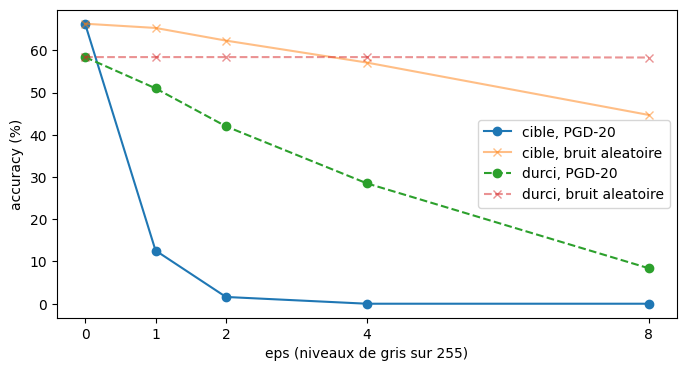

In [41]:
plt.figure(figsize=(8, 4))
for nom, tab, style in [("cible", adv_cible, "-"), ("durci", adv_durci, "--")]:
    plt.plot([0] + EPS, [tab.loc["PGD-20", "sans attaque"]] + list(tab.loc["PGD-20"].iloc[1:]), style, marker="o", label=f"{nom}, PGD-20")
    plt.plot([0] + EPS, [tab.loc["bruit aleatoire", "sans attaque"]] + list(tab.loc["bruit aleatoire"].iloc[1:]), style,
             marker="x", alpha=0.5, label=f"{nom}, bruit aleatoire")
plt.xlabel("eps (niveaux de gris sur 255)"); plt.ylabel("accuracy (%)")
plt.xticks([0] + EPS)
plt.legend()
plt.show()

**Lecture.** Le modèle durci illustre le compromis entre robustesse et précision (H9 confirmée). Il gagne énormément en robustesse : +40 points sous PGD à 2/255 (1,6 % → 42,0 %), l'attaque ciblée vers « Joie » ne réussit plus que 20 % du temps au lieu de 94 %, et les attaques transférées ne marchent presque plus (56,1 % d'accuracy à 4/255 au lieu de 4,8 %). Tous les contrôles passent sur le modèle durci, y compris celui du bruit aléatoire (−0,1 point contre −42) : le gain n'est pas un masquage de gradient. Surtout, le **scénario webcam passe de 17,8 % à 53,9 %**, et le modèle progresse aussi un peu sur le flou et le JPEG, qu'il n'a jamais vus (+2,2 points).

Le prix est lourd : −7,7 points sur les images normales (65,9 % → 58,2 %, McNemar p = 6·10⁻²⁴), −9 points de balanced accuracy, et −8,7 points en rotation, que la cible gérait bien. Deux raisons probables : l'entraînement adversarial demande plus d'epochs (il a été arrêté à 30 alors que sa validation montait encore), et les dégradations les plus fortes rendent une partie des images d'entraînement presque illisibles. Deux problèmes ne bougent pas : le masque (la joie reste à 1 %) et les non-visages (86 % acceptés). Ils ne viennent pas d'un manque de robustesse mais de ce que le modèle regarde et de la question qu'on lui pose ; aucun entraînement de ce type ne les règle.

Pour le projet, on en tire l'expérience E5 du notebook principal : garder les dégradations « conditions réelles », sans l'entraînement adversarial, qui ne sert que contre un attaquant.

## 9. Bilan

### Hypothèses

On reprend les hypothèses de la partie 0, chacune avec le critère qu'on s'était donné. Le verdict est calculé à partir des résultats, pas écrit à la main.

In [42]:
p_fisher = stats.fisher_exact([[bon_te[quasi_te].sum(), (~bon_te[quasi_te]).sum()],
                               [bon_te[~quasi_te].sum(), (~bon_te[~quasi_te]).sum()]])[1] if quasi_te.sum() else 1.0
perte3 = acc_propre - corr_cible["niv. 3"]
verdicts = [
    ("H1", "doublons train/test qui gonflent le score", "accuracy plus haute sur les doublons, Fisher p < 0,05",
     quasi_te.sum() > 0 and bon_te[quasi_te].mean() > bon_te[~quasi_te].mean() and p_fisher < 0.05,
     f"{quasi_te.sum()} doublons, p = {p_fisher:.2g}"),
    ("H2", "beaucoup d'erreurs sont des erreurs d'annotation", ">= 20 % des erreurs d'accord avec FER+",
     part_fausses_erreurs >= 0.20, f"{100 * part_fausses_erreurs:.0f} %"),
    ("H3", "modele sur-confiant", "T > 1 et ECE avant calibration > 3 %",
     T_cible > 1 and ece(softmax(z_te), y_te) > 0.03, f"T = {T_cible:.2f}, ECE = {100 * ece(softmax(z_te), y_te):.1f} %"),
    ("H4", "cadrage / basse resolution pires que bruit / JPEG", "au niv. 3, max(cadrage, basse res.) > max(bruit, JPEG)",
     max(perte3["cadrage"], perte3["basse resolution"]) > max(perte3["bruit"], perte3["JPEG"]),
     f"cadrage -{perte3['cadrage']:.1f}, basse res. -{perte3['basse resolution']:.1f}, bruit -{perte3['bruit']:.1f}, JPEG -{perte3['JPEG']:.1f} pts"),
    ("H5", "la joie depend de la bouche", "rappel Joie perd > 30 pts avec le masque",
     occ_cible.loc["Joie", "aucune"] - occ_cible.loc["Joie", "masque chirurgical"] > 30,
     f"{occ_cible.loc['Joie', 'aucune']:.0f} % -> {occ_cible.loc['Joie', 'masque chirurgical']:.0f} %"),
    ("H6", "2/255 suffit sans defense", "PGD-20 a 2/255 < 10 %",
     adv_cible.loc["PGD-20", "eps = 2/255"] < 10, f"{adv_cible.loc['PGD-20', 'eps = 2/255']:.1f} %"),
    ("H7", "les attaques transferent", "a 4/255, transfert >= 10 pts sous le temoin bruit",
     transfert_cible.loc["eps = 4/255", "temoin bruit %"] - transfert_cible.loc["eps = 4/255", "accuracy sous transfert %"] >= 10,
     f"{transfert_cible.loc['eps = 4/255', 'accuracy sous transfert %']:.1f} % contre {transfert_cible.loc['eps = 4/255', 'temoin bruit %']:.1f} %"),
    ("H8", "pas capable de rejeter les non-visages", "> 20 % de CIFAR-10 passe le seuil de rejet",
     ood_cible.loc["CIFAR-10", "acceptees au seuil %"] > 20, f"{ood_cible.loc['CIFAR-10', 'acceptees au seuil %']:.0f} % acceptees"),
    ("H9", "l'entrainement adversarial aide, avec un cout", "PGD 2/255 gagne >= 20 pts et accuracy normale perd >= 1 pt",
     comparaison.loc["PGD-20, eps 2/255 (%)", "ecart"] >= 20 and comparaison.loc["accuracy test (%)", "ecart"] <= -1,
     f"PGD {comparaison.loc['PGD-20, eps 2/255 (%)', 'ecart']:+.1f} pts, normale {comparaison.loc['accuracy test (%)', 'ecart']:+.1f} pts"),
]
verdicts = [(h, texte, critere, "oui" if ok else "non", mesure) for h, texte, critere, ok, mesure in verdicts]
display(pd.DataFrame(verdicts, columns=["", "hypothese", "critere", "confirmee", "mesure"]).set_index(""))

,hypothese,critere,confirmee,mesure
,,,,
H1,doublons train/test qui gonflent le score,"accuracy plus haute sur les doublons, Fisher p...",oui,"465 doublons, p = 3.7e-06"
H2,beaucoup d'erreurs sont des erreurs d'annotation,>= 20 % des erreurs d'accord avec FER+,oui,44 %
H3,modele sur-confiant,T > 1 et ECE avant calibration > 3 %,non,"T = 1.21, ECE = 2.2 %"
H4,cadrage / basse resolution pires que bruit / JPEG,"au niv. 3, max(cadrage, basse res.) > max(brui...",non,"cadrage -2.7, basse res. -18.7, bruit -41.6, J..."
H5,la joie depend de la bouche,rappel Joie perd > 30 pts avec le masque,oui,88 % -> 0 %
H6,2/255 suffit sans defense,PGD-20 a 2/255 < 10 %,oui,1.6 %
H7,les attaques transferent,"a 4/255, transfert >= 10 pts sous le temoin bruit",oui,4.8 % contre 57.1 %
H8,pas capable de rejeter les non-visages,> 20 % de CIFAR-10 passe le seuil de rejet,oui,88 % acceptees
H9,"l'entrainement adversarial aide, avec un cout",PGD 2/255 gagne >= 20 pts et accuracy normale ...,oui,"PGD +40.4 pts, normale -7.7 pts"


### Constats classés par gravité

La gravité suit la grille de la partie 0. L'impact est la perte d'accuracy en points, sauf pour les entrées hors domaine où c'est la part d'images non-visages acceptées par le seuil de rejet.

In [43]:
def gravite(impact, sans_attaquant, sans_acces=False, score=False):
    if score:
        return "critique" if abs(impact) > 2 else "moyenne"
    if sans_attaquant:
        return "critique" if impact > SEUIL_CRITIQUE else ("elevee" if impact > SEUIL_ELEVE else "moyenne")
    if sans_acces:
        return "elevee" if impact > SEUIL_ELEVE else "moyenne"
    return "moyenne"   # boite blanche : acces privilegie

pire = perte3.idxmax()
acc_e = adv_cible.loc["PGD-20", "sans attaque"]
constats = [
    ("A", "score gonfle par les doublons", f"{ecart_doublons:+.2f} pts", gravite(ecart_doublons, True, score=True),
     "annoncer aussi le score sans doublons"),
    ("A", "labels FER2013 contestes par FER+", f"{100 * np.mean(yfp_te[ok_te] != y_te[ok_te]):.0f} % des labels de test",
     gravite(100 * ((pred_te == yfp_te)[ok_te].mean() - bon_te[ok_te].mean()), True, score=True),
     "evaluer aussi avec FER+, ou entrainer sur FER+"),
    ("B", f"pire degradation au niv. 3 : {pire}", f"-{perte3[pire]:.1f} pts", gravite(perte3[pire], True),
     "augmentation 'conditions reelles'"),
    ("B", "scenario webcam", f"-{acc_propre - webcam_cible:.1f} pts", gravite(acc_propre - webcam_cible, True),
     "augmentation + marge de recadrage YOLO calibree"),
    ("B", "masque chirurgical", f"-{occ_cible.loc['TOUTES (accuracy)', 'aucune'] - occ_cible.loc['TOUTES (accuracy)', 'masque chirurgical']:.1f} pts",
     gravite(occ_cible.loc["TOUTES (accuracy)", "aucune"] - occ_cible.loc["TOUTES (accuracy)", "masque chirurgical"], True),
     "signaler 'visage partiellement cache' plutot que predire"),
    ("C", "non-visages acceptes (CIFAR-10)", f"{ood_cible.loc['CIFAR-10', 'acceptees au seuil %']:.0f} % acceptes",
     gravite(ood_cible.loc["CIFAR-10", "acceptees au seuil %"], True), "seuil de rejet + score du detecteur"),
    ("D", "PGD boite blanche, 2/255", f"-{acc_e - adv_cible.loc['PGD-20', 'eps = 2/255']:.1f} pts",
     gravite(acc_e - adv_cible.loc["PGD-20", "eps = 2/255"], False), "entrainement adversarial"),
    ("E", "transfert depuis un substitut, 4/255",
     f"-{acc_e - transfert_cible.loc['eps = 4/255', 'accuracy sous transfert %']:.1f} pts",
     gravite(acc_e - transfert_cible.loc["eps = 4/255", "accuracy sous transfert %"], False, sans_acces=True),
     "entrainement adversarial"),
    ("F", "patch universel sur le front -> Joie",
     f"{res_patch_cible['patch optimise']:.0f} % de reussite (temoin {res_patch_cible['temoin : bruit']:.0f} %)",
     gravite(res_patch_cible["patch optimise"] - res_patch_cible["temoin : bruit"], False, sans_acces=True),
     "entrainement adversarial, detection de patch"),
]
ordre = {"critique": 0, "elevee": 1, "moyenne": 2}
bilan = pd.DataFrame(constats, columns=["scenario", "constat", "mesure", "gravite", "piste"])
bilan = bilan.sort_values("gravite", key=lambda s: s.map(ordre)).reset_index(drop=True)
display(bilan)

,scenario,constat,mesure,gravite,piste
0,A,labels FER2013 contestes par FER+,34 % des labels de test,critique,"evaluer aussi avec FER+, ou entrainer sur FER+"
1,B,pire degradation au niv. 3 : bruit,-41.6 pts,critique,augmentation 'conditions reelles'
2,B,scenario webcam,-48.1 pts,critique,augmentation + marge de recadrage YOLO calibree
3,B,masque chirurgical,-37.6 pts,critique,signaler 'visage partiellement cache' plutot q...
4,C,non-visages acceptes (CIFAR-10),88 % acceptes,critique,seuil de rejet + score du detecteur
5,E,"transfert depuis un substitut, 4/255",-61.5 pts,elevee,entrainement adversarial
6,F,patch universel sur le front -> Joie,19 % de reussite (temoin 6 %),elevee,"entrainement adversarial, detection de patch"
7,A,score gonfle par les doublons,+1.39 pts,moyenne,annoncer aussi le score sans doublons
8,D,"PGD boite blanche, 2/255",-64.7 pts,moyenne,entrainement adversarial


**Lecture.** Sept hypothèses sur neuf sont confirmées. Les deux qui tombent sont instructives : le modèle n'est pas sur-confiant (H3), et c'est le bruit, pas le cadrage, qui fait le plus de dégâts (H4). L'augmentation géométrique protégeait déjà du cadrage ; rien ne protégeait du bruit.

Le classement met en tête cinq constats **critiques**, qui arrivent tous sans attaquant : les labels contestés (un tiers du test), le bruit (−41,6 points), le scénario webcam (−48,1 points), le masque (−37,6 points) et les non-visages acceptés (88 %). Les attaques adversariales, spectaculaires en chiffres, viennent après : le transfert et le patch sont « élevés » parce qu'ils ne demandent pas nos poids ; l'attaque en boîte blanche est « moyenne » parce qu'elle suppose un accès qu'un attaquant n'aura pas. Pour un système montré à la webcam, la priorité est claire : la robustesse aux conditions réelles d'abord, la sécurité ensuite.

Ce qu'on a mis en place dans le notebook principal à partir de ce bilan : l'augmentation « conditions réelles » (expérience E5), un recadrage des visages YOLO calibré sur la validation, le filtrage des non-visages par le score de YOLO plutôt que par la confiance du CNN, et un lissage des prédictions en vidéo.

### Ce que cette red team ne couvre pas

Pour être honnêtes sur la portée du travail :

- **Équité.** FER2013 ne donne ni l'âge, ni le genre, ni la couleur de peau des personnes. On ne peut donc pas mesurer si le modèle marche moins bien pour certains groupes, alors que c'est un problème documenté en reconnaissance d'expressions (Xu et al., 2020). Pour le faire sérieusement, il faudrait un jeu annoté comme RAF-DB, qui fournit ces attributs. Utiliser la luminosité moyenne de l'image comme substitut de la couleur de peau serait trompeur : elle dépend surtout de l'éclairage.
- **Le détecteur.** On n'attaque que le CNN. YOLO a ses propres faiblesses (visages de profil, petits visages, faux positifs), qu'il faudrait évaluer à part.
- **L'empoisonnement des données et les portes dérobées.** Quelqu'un qui pourrait glisser des images dans le train pourrait implanter un déclencheur. On ne le teste pas : nos données viennent d'un fichier figé et vérifié.
- **La vie privée.** On ne teste ni l'extraction du modèle par requêtes, ni l'inférence d'appartenance (retrouver si une photo était dans le train). Ce n'est pas anodin : FER2013 contient des photos de vraies personnes récupérées sur le web.
- **Le monde physique.** Le patch reste numérique, et les dégradations sont simulées. Un test sur de vraies vidéos de webcam, même courtes, serait la suite logique (partie 9 du projet).

### Ce que le modèle mesure vraiment

Dernier point, qui n'est pas technique mais compte pour la soutenance. Le modèle ne détecte pas des émotions : il reconnaît des configurations du visage qui ressemblent à celles que les gens ont associées à des mots-clés comme "furieux" ou "ravi" dans des résultats de recherche d'images. Une revue de la littérature en psychologie (Barrett et al., 2019) montre que le lien entre une configuration du visage et l'émotion ressentie est bien plus faible et plus dépendant du contexte qu'on le suppose souvent. C'est aussi la position du droit européen : le règlement sur l'IA (règlement (UE) 2024/1689, article 5, paragraphe 1, point f) interdit depuis le 2 février 2025 les systèmes qui infèrent les émotions des personnes sur le lieu de travail et dans les établissements d'enseignement, sauf pour des raisons médicales ou de sécurité. Un projet de cours relève de la recherche et du développement, mais déployer ce système pour observer des élèves ou des salariés serait interdit. Dans la démo, on parle donc d'"expression affichée", pas d'"émotion".

## Références

- Athalye, Carlini, Wagner (2018). *Obfuscated Gradients Give a False Sense of Security*. ICML.
- Athalye, Engstrom, Ilyas, Kwok (2018). *Synthesizing Robust Adversarial Examples*. ICML.
- Barrett, Adolphs, Marsella, Martinez, Pollak (2019). *Emotional Expressions Reconsidered*. Psychological Science in the Public Interest, 20(1).
- Barsoum, Zhang, Canton Ferrer, Zhang (2016). *Training Deep Networks for Facial Expression Recognition with Crowd-Sourced Label Distribution*. ICMI. (FER+, github.com/microsoft/FERPlus)
- Brown, Mané, Roy, Abadi, Gilmer (2017). *Adversarial Patch*. arXiv:1712.09665.
- Carlini, Athalye, Papernot et al. (2019). *On Evaluating Adversarial Robustness*. arXiv:1902.06705.
- Dong, Liao, Pang et al. (2018). *Boosting Adversarial Attacks with Momentum*. CVPR.
- Geirhos, Jacobsen, Michaelis et al. (2020). *Shortcut Learning in Deep Neural Networks*. Nature Machine Intelligence, 2.
- Goodfellow, Erhan, Carrier et al. (2013). *Challenges in Representation Learning: A Report on Three Machine Learning Contests*. ICONIP. (FER2013)
- Goodfellow, Shlens, Szegedy (2015). *Explaining and Harnessing Adversarial Examples*. ICLR.
- Guo, Pleiss, Sun, Weinberger (2017). *On Calibration of Modern Neural Networks*. ICML.
- Hendrycks, Dietterich (2019). *Benchmarking Neural Network Robustness to Common Corruptions and Perturbations*. ICLR.
- Hendrycks, Gimpel (2017). *A Baseline for Detecting Misclassified and Out-of-Distribution Examples in Neural Networks*. ICLR.
- Liu, Wang, Owens, Li (2020). *Energy-based Out-of-distribution Detection*. NeurIPS.
- Madry, Makelov, Schmidt, Tsipras, Vladu (2018). *Towards Deep Learning Models Resistant to Adversarial Attacks*. ICLR.
- Papernot, McDaniel, Goodfellow et al. (2017). *Practical Black-Box Attacks against Machine Learning*. AsiaCCS.
- Rice, Wong, Kolter (2020). *Overfitting in Adversarially Robust Deep Learning*. ICML.
- Wong, Rice, Kolter (2020). *Fast is Better than Free: Revisiting Adversarial Training*. ICLR.
- Xu, White, Kalkan, Gunes (2020). *Investigating Bias and Fairness in Facial Expression Recognition*. ECCV Workshops.
- Zeiler, Fergus (2014). *Visualizing and Understanding Convolutional Networks*. ECCV.
- Règlement (UE) 2024/1689 du 13 juin 2024 établissant des règles harmonisées concernant l'intelligence artificielle, article 5.